# Global Defense Sector Analysis

This project analyzes the performance of 42 publicly traded defense-related companies from 15 countries between January 2022 and August 2026.

The analysis examines cumulative stock returns, volatility, business segments, geographic distribution, reactions to major geopolitical events, trading volume, correlations, and performance relative to major market benchmarks.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


## 2. Define Defense Companies and Asset Selection

The dataset covers 15 countries across North America, Europe, Asia and Australia and represents different business models, including traditional defense contractors, aerospace and industrial defense companies, defense technology and electronics firms, and defense software and services providers.

Only publicly traded companies with sufficient historical market data were included. The sample is not intended to represent the entire global defense industry or a market-cap-weighted index, but rather a diverse cross-section of major listed defense-related companies.

Major stock market indices, gold, and Brent crude oil were included as benchmarks. They provide additional context for assessing how the defense sector performed relative to broader financial markets and other assets that may respond to geopolitical developments.


In [2]:
# Dictionary of defense companies and their Yahoo Finance ticker symbols
companies = {
    # United States
    "Lockheed Martin": "LMT",
    "RTX": "RTX",
    "Northrop Grumman": "NOC",
    "General Dynamics": "GD",
    "L3Harris Technologies": "LHX",
    "Huntington Ingalls Industries": "HII",
    "Palantir": "PLTR",
    "BigBear.ai": "BBAI",
    "Kratos Defense": "KTOS",
    "Leidos": "LDOS",
    "CACI International": "CACI",
    "Booz Allen Hamilton": "BAH",

    # United Kingdom
    "BAE Systems": "BA.L",
    "Babcock International": "BAB.L",
    "QinetiQ": "QQ.L",
    "Chemring Group": "CHG.L",

    # Germany
    "Rheinmetall": "RHM.DE",
    "Hensoldt": "HAG.DE",

    # France
    "Thales": "HO.PA",
    "Dassault Aviation": "AM.PA",
    "Safran": "SAF.PA",
    
    # France / Netherlands
    "Airbus": "AIR.PA",


    # Italy
    "Leonardo": "LDO.MI",
    "Fincantieri": "FCT.MI",

    # Sweden
    "Saab": "SAAB-B.ST",

    # Norway
    "Kongsberg Gruppen": "KOG.OL",

    # Spain
    "Indra Sistemas": "IDR.MC",

    # Israel
    "Elbit Systems": "ESLT",

    # South Korea
    "Hanwha Aerospace": "012450.KS",
    "Korea Aerospace Industries": "047810.KS",
    "LIG Nex1": "079550.KS",

    # India
    "Hindustan Aeronautics": "HAL.NS",
    "Bharat Electronics": "BEL.NS",
    "Bharat Dynamics": "BDL.NS",

    # Japan
    "Mitsubishi Heavy Industries": "7011.T",
    "Kawasaki Heavy Industries": "7012.T",

    # Australia
    "Austal": "ASB.AX",
   
    # China
    "AVIC Xi'an Aircraft Industry": "000768.SZ",
    "AVIC Shenyang Aircraft": "600760.SS",
    "AVIC Airborne Systems": "600372.SS",
    "AECC Aviation Power": "600893.SS",
    "China Spacesat": "600118.SS",

}


## 3. Download Historical Market Data


In [3]:
# Download historical stock price data for all selected defense companies

raw_stock_data  = yf.download(
    list(companies.values()),
    start="2020-01-01",
    end="2026-09-01",
    auto_adjust=True,
    progress=False
)

print(raw_stock_data)

# Download market benchmarks
benchmarks = {
    "USA - S&P 500": "^GSPC",
    "Germany - DAX": "^GDAXI",
    "Europe - Euro Stoxx 50": "^STOXX50E",
    "China - CSI 300": "000300.SS",
    "Gold": "GC=F",
    "Brent Oil": "BZ=F"
}

benchmark_data = yf.download(
    list(benchmarks.values()),
    start="2022-01-01",
    end="2026-09-01",
    auto_adjust=True,
    progress=False
)["Close"]

benchmark_data = benchmark_data.rename(
    columns={ticker: name for name, ticker in benchmarks.items()}
)


Price           Close                                                         \
Ticker      000768.SZ     012450.KS      047810.KS      079550.KS  600118.SS   
Date                                                                           
2020-01-01        NaN           NaN            NaN            NaN        NaN   
2020-01-02  15.993031  3.549041e+04   32510.935547   28868.746094  21.247591   
2020-01-03  16.457159  3.564383e+04   32655.212891   29868.923828  21.838898   
2020-01-06  16.515175  3.595066e+04   32607.123047   30550.863281  21.996578   
2020-01-07  16.495836  3.543927e+04   32414.748047   29868.923828  22.193682   
...               ...           ...            ...            ...        ...   
2026-08-25  20.459999  1.102000e+06  130900.000000  718000.000000  60.240002   
2026-08-26  20.719999  1.087000e+06  132100.000000  710000.000000  60.200001   
2026-08-27  21.200001  1.150000e+06  137600.000000  745000.000000  61.599998   
2026-08-28  21.719999  1.157000e+06  133

In [4]:
# Review the available date range for each ticker
for ticker in raw_stock_data["Close"].columns:
    ticker_prices = raw_stock_data["Close"][ticker].dropna()

    print(
        ticker,
        ticker_prices.index.min(),
        ticker_prices.index.max(),
        len(ticker_prices)
    )


000768.SZ 2020-01-02 00:00:00 2026-08-31 00:00:00 1615
012450.KS 2020-01-02 00:00:00 2026-08-31 00:00:00 1632
047810.KS 2020-01-02 00:00:00 2026-08-31 00:00:00 1632
079550.KS 2020-01-02 00:00:00 2026-08-31 00:00:00 1632
600118.SS 2020-01-02 00:00:00 2026-08-31 00:00:00 1615
600372.SS 2020-01-02 00:00:00 2026-08-31 00:00:00 1615
600760.SS 2020-01-02 00:00:00 2026-08-31 00:00:00 1615
600893.SS 2020-01-02 00:00:00 2026-08-31 00:00:00 1615
7011.T 2020-01-06 00:00:00 2026-08-31 00:00:00 1626
7012.T 2020-01-06 00:00:00 2026-08-31 00:00:00 1626
AIR.PA 2020-01-02 00:00:00 2026-08-31 00:00:00 1707
AM.PA 2020-01-02 00:00:00 2026-08-31 00:00:00 1707
ASB.AX 2020-01-02 00:00:00 2026-08-31 00:00:00 1687
BA.L 2020-01-02 00:00:00 2026-08-28 00:00:00 1682
BAB.L 2020-01-02 00:00:00 2026-08-28 00:00:00 1682
BAH 2020-01-02 00:00:00 2026-08-31 00:00:00 1674
BBAI 2021-04-05 00:00:00 2026-08-31 00:00:00 1359
BDL.NS 2020-01-01 00:00:00 2026-08-31 00:00:00 1654
BEL.NS 2020-01-01 00:00:00 2026-08-31 00:00:00 16

In [5]:
# Count non-missing closing prices for each ticker
ticker_counts = raw_stock_data["Close"].notna().sum().sort_values()
print(ticker_counts)


Ticker
BBAI         1359
PLTR         1486
HAG.DE       1510
000768.SZ    1615
600893.SS    1615
600118.SS    1615
600372.SS    1615
600760.SS    1615
7012.T       1626
7011.T       1626
047810.KS    1632
012450.KS    1632
079550.KS    1632
BDL.NS       1654
HAL.NS       1654
BEL.NS       1654
KTOS         1674
KOG.OL       1674
HII          1674
CACI         1674
ESLT         1674
GD           1674
LDOS         1674
BAH          1674
LHX          1674
LMT          1674
RTX          1674
NOC          1674
SAAB-B.ST    1675
CHG.L        1682
BA.L         1682
BAB.L        1682
QQ.L         1682
ASB.AX       1687
LDO.MI       1695
FCT.MI       1695
RHM.DE       1697
IDR.MC       1705
AM.PA        1707
AIR.PA       1707
HO.PA        1707
SAF.PA       1707
dtype: int64


## 4. Reshape and Clean Historical Data


In [6]:
# Convert the downloaded stock data from wide to long format

raw_long_data = (
    raw_stock_data
    .stack(level="Ticker", future_stack=True)
    .reset_index()
)

print(raw_long_data)


Price       Date     Ticker        Close         High          Low  \
0     2020-01-01  000768.SZ          NaN          NaN          NaN   
1     2020-01-01  012450.KS          NaN          NaN          NaN   
2     2020-01-01  047810.KS          NaN          NaN          NaN   
3     2020-01-01  079550.KS          NaN          NaN          NaN   
4     2020-01-01  600118.SS          NaN          NaN          NaN   
...          ...        ...          ...          ...          ...   
73117 2026-08-31       QQ.L          NaN          NaN          NaN   
73118 2026-08-31     RHM.DE  1110.800049  1157.000000  1110.800049   
73119 2026-08-31        RTX   207.729996   211.240005   207.690002   
73120 2026-08-31  SAAB-B.ST   632.900024   641.299988   630.900024   
73121 2026-08-31     SAF.PA   337.000000   343.600006   334.700012   

Price         Open     Volume  
0              NaN        NaN  
1              NaN        NaN  
2              NaN        NaN  
3              NaN        NaN  

In [7]:
# Remove rows where no closing price is available
long_data = raw_long_data.dropna(subset=["Close"]).copy()

print(long_data)


Price       Date     Ticker         Close          High           Low  \
17    2020-01-01     BDL.NS    135.852524    137.745380    133.115861   
18    2020-01-01     BEL.NS     29.673433     29.910468     29.451216   
25    2020-01-01     HAL.NS    306.537842    308.615856    306.453877   
42    2020-01-02  000768.SZ     15.993031     16.215424     15.867329   
43    2020-01-02  012450.KS  35490.410156  36104.074858  35439.270532   
...          ...        ...           ...           ...           ...   
73116 2026-08-31       PLTR    186.380005    187.940002    183.789993   
73118 2026-08-31     RHM.DE   1110.800049   1157.000000   1110.800049   
73119 2026-08-31        RTX    207.729996    211.240005    207.690002   
73120 2026-08-31  SAAB-B.ST    632.900024    641.299988    630.900024   
73121 2026-08-31     SAF.PA    337.000000    343.600006    334.700012   

Price          Open      Volume  
17       134.552606     63494.0  
18        29.717880  15438294.0  
25       308.552876  

## 5. Check Trading Currencies

The selected companies are traded in different local currencies. This step documents the trading currency of each ticker.

Returns in this project are calculated in each security's local trading currency and are not adjusted for foreign-exchange movements. Therefore, the results show the performance of the stocks in their local markets, but they do not represent the exact return that an investor using a single base currency, such as EUR or USD, would have achieved.

Historical price data are downloaded with `auto_adjust=True`. Return calculations therefore use Yahoo Finance adjusted closing prices, which incorporate split and cash-dividend adjustments. The resulting returns can be interpreted as an approximation of total return in each security's local trading currency; they are not adjusted for foreign-exchange movements.


In [8]:
# Check the trading currency for each company
for ticker in companies.values():
    currency = yf.Ticker(ticker).fast_info["currency"]
    print(ticker, currency)


LMT USD
RTX USD
NOC USD
GD USD
LHX USD
HII USD
PLTR USD
BBAI USD
KTOS USD
LDOS USD
CACI USD
BAH USD
BA.L GBp
BAB.L GBp
QQ.L GBp
CHG.L GBp
RHM.DE EUR
HAG.DE EUR
HO.PA EUR
AM.PA EUR
SAF.PA EUR
AIR.PA EUR
LDO.MI EUR
FCT.MI EUR
SAAB-B.ST SEK
KOG.OL NOK
IDR.MC EUR
ESLT USD
012450.KS KRW
047810.KS KRW
079550.KS KRW
HAL.NS INR
BEL.NS INR
BDL.NS INR
7011.T JPY
7012.T JPY
ASB.AX AUD
000768.SZ CNY
600760.SS CNY
600372.SS CNY
600893.SS CNY
600118.SS CNY


## 6. Classify Defense Companies

Two levels of classification are used in this project.

The **Defense_Type** variable provides a more detailed description of each company's main defense-related business activity, such as defense-focused manufacturing, aerospace and defense, naval defense, defense electronics, or defense software and services.

For the comparative analysis, these detailed categories are combined into four broader **Analysis_Group** categories:

- **Traditional Defense**
- **Aerospace / Industrial Defense**
- **Defense Technology / Electronics**
- **Defense Software / AI / Services**

The broader groups are used to make comparisons between business models easier. They are analytical categories created for this project and are not intended to represent an official industry classification.


In [9]:
# Create company metadata with ticker, company, country, currency and defense type

defense_type = {
    # United States
    "Lockheed Martin": "Defense-focused",
    "RTX": "Aerospace & Defense",
    "Northrop Grumman": "Defense-focused",
    "General Dynamics": "Defense-focused",
    "L3Harris Technologies": "Defense Technology",
    "Huntington Ingalls Industries": "Naval Defense",
    "Palantir": "Defense Software / AI",
    "BigBear.ai": "Defense Software / AI",
    "Kratos Defense": "Defense Technology",
    "Leidos": "Defense IT / Services",
    "CACI International": "Defense IT / Services",
    "Booz Allen Hamilton": "Defense IT / Services",

    # United Kingdom
    "BAE Systems": "Defense-focused",
    "Babcock International": "Defense Services",
    "QinetiQ": "Defense Technology",
    "Chemring Group": "Defense-focused",

    # Germany
    "Rheinmetall": "Defense-focused",
    "Hensoldt": "Defense Electronics",

    # France
    "Thales": "Aerospace & Defense",
    "Dassault Aviation": "Aerospace & Defense",
    "Safran": "Aerospace & Defense",
     
    # France / Netherlands
    "Airbus": "Aerospace & Defense",

    # Italy
    "Leonardo": "Aerospace & Defense",
    "Fincantieri": "Naval / Diversified",

    # Sweden
    "Saab": "Defense-focused",

    # Norway
    "Kongsberg Gruppen": "Diversified + Defense",

    # Spain
    "Indra Sistemas": "Technology + Defense",

    # Israel
    "Elbit Systems": "Defense-focused",

    # South Korea
    "Hanwha Aerospace": "Aerospace & Defense",
    "Korea Aerospace Industries": "Aerospace & Defense",
    "LIG Nex1": "Defense-focused",

    # India
    "Hindustan Aeronautics": "Aerospace & Defense",
    "Bharat Electronics": "Defense Electronics",
    "Bharat Dynamics": "Defense-focused",

    # Japan
    "Mitsubishi Heavy Industries": "Diversified + Defense",
    "Kawasaki Heavy Industries": "Diversified + Defense",

    # Australia
    "Austal": "Naval Defense",

    # China
    "AVIC Xi'an Aircraft Industry": "Aerospace & Defense",
    "AVIC Shenyang Aircraft": "Aerospace & Defense",
    "AVIC Airborne Systems": "Defense Electronics",
    "AECC Aviation Power": "Aerospace & Defense",
    "China Spacesat": "Defense Technology",
}

# Build the complete metadata table
metadata = []

for company, ticker in companies.items():
    info = yf.Ticker(ticker).info

    metadata.append({
        "Ticker": ticker,
        "Company": company,
        "Country": info.get("country"),
        "Currency": info.get("currency"),
        "Defense_Type": defense_type.get(company)
    })

company_metadata = pd.DataFrame(metadata)

print(company_metadata)


       Ticker                        Company         Country Currency  \
0         LMT                Lockheed Martin   United States      USD   
1         RTX                            RTX   United States      USD   
2         NOC               Northrop Grumman   United States      USD   
3          GD               General Dynamics   United States      USD   
4         LHX          L3Harris Technologies   United States      USD   
5         HII  Huntington Ingalls Industries   United States      USD   
6        PLTR                       Palantir   United States      USD   
7        BBAI                     BigBear.ai   United States      USD   
8        KTOS                 Kratos Defense   United States      USD   
9        LDOS                         Leidos   United States      USD   
10       CACI             CACI International   United States      USD   
11        BAH            Booz Allen Hamilton   United States      USD   
12       BA.L                    BAE Systems  Unite

In [10]:
# Add broader groups for analysis and charts
analysis_group = {
    # Traditional Defense
    "Lockheed Martin": "Traditional Defense",
    "Northrop Grumman": "Traditional Defense",
    "General Dynamics": "Traditional Defense",
    "Huntington Ingalls Industries": "Traditional Defense",
    "BAE Systems": "Traditional Defense",
    "Chemring Group": "Traditional Defense",
    "Rheinmetall": "Traditional Defense",
    "Saab": "Traditional Defense",
    "Elbit Systems": "Traditional Defense",
    "LIG Nex1": "Traditional Defense",
    "Bharat Dynamics": "Traditional Defense",

    # Aerospace / Industrial Defense
    "RTX": "Aerospace / Industrial Defense",
    "Thales": "Aerospace / Industrial Defense",
    "Dassault Aviation": "Aerospace / Industrial Defense",
    "Airbus": "Aerospace / Industrial Defense",
    "Safran": "Aerospace / Industrial Defense",
    "Leonardo": "Aerospace / Industrial Defense",
    "Fincantieri": "Aerospace / Industrial Defense",
    "Hanwha Aerospace": "Aerospace / Industrial Defense",
    "Korea Aerospace Industries": "Aerospace / Industrial Defense",
    "Hindustan Aeronautics": "Aerospace / Industrial Defense",
    "Mitsubishi Heavy Industries": "Aerospace / Industrial Defense",
    "Kawasaki Heavy Industries": "Aerospace / Industrial Defense",
    "Kongsberg Gruppen": "Aerospace / Industrial Defense",
    "Austal": "Aerospace / Industrial Defense",

    # Defense Technology / Electronics
    "L3Harris Technologies": "Defense Technology / Electronics",
    "Kratos Defense": "Defense Technology / Electronics",
    "QinetiQ": "Defense Technology / Electronics",
    "Hensoldt": "Defense Technology / Electronics",
    "Indra Sistemas": "Defense Technology / Electronics",
    "Bharat Electronics": "Defense Technology / Electronics",

    # Defense Software / AI / Services
    "Palantir": "Defense Software / AI / Services",
    "BigBear.ai": "Defense Software / AI / Services",
    "Leidos": "Defense Software / AI / Services",
    "CACI International": "Defense Software / AI / Services",
    "Booz Allen Hamilton": "Defense Software / AI / Services",
    "Babcock International": "Defense Software / AI / Services",

    # China
    "AVIC Xi'an Aircraft Industry": "Aerospace / Industrial Defense",
    "AVIC Shenyang Aircraft": "Aerospace / Industrial Defense",
    "AVIC Airborne Systems": "Defense Technology / Electronics",
    "AECC Aviation Power": "Aerospace / Industrial Defense",
    "China Spacesat": "Defense Technology / Electronics",


}

# Add the broader analysis group to the metadata table
company_metadata["Analysis_Group"] = (
    company_metadata["Company"].map(analysis_group)
)

print(company_metadata[
    ["Ticker", "Company", "Defense_Type", "Analysis_Group"]
])


       Ticker                        Company           Defense_Type  \
0         LMT                Lockheed Martin        Defense-focused   
1         RTX                            RTX    Aerospace & Defense   
2         NOC               Northrop Grumman        Defense-focused   
3          GD               General Dynamics        Defense-focused   
4         LHX          L3Harris Technologies     Defense Technology   
5         HII  Huntington Ingalls Industries          Naval Defense   
6        PLTR                       Palantir  Defense Software / AI   
7        BBAI                     BigBear.ai  Defense Software / AI   
8        KTOS                 Kratos Defense     Defense Technology   
9        LDOS                         Leidos  Defense IT / Services   
10       CACI             CACI International  Defense IT / Services   
11        BAH            Booz Allen Hamilton  Defense IT / Services   
12       BA.L                    BAE Systems        Defense-focused   
13    

## 7. Build and Validate the Analysis Dataset


In [11]:
# Add company metadata to the historical price data
data = long_data.merge(
    company_metadata,
    on="Ticker",
    how="left",
    validate="many_to_one"
)

print(data.head())


        Date     Ticker         Close          High           Low  \
0 2020-01-01     BDL.NS    135.852524    137.745380    133.115861   
1 2020-01-01     BEL.NS     29.673433     29.910468     29.451216   
2 2020-01-01     HAL.NS    306.537842    308.615856    306.453877   
3 2020-01-02  000768.SZ     15.993031     16.215424     15.867329   
4 2020-01-02  012450.KS  35490.410156  36104.074858  35439.270532   

           Open      Volume                       Company      Country  \
0    134.552606     63494.0               Bharat Dynamics        India   
1     29.717880  15438294.0            Bharat Electronics        India   
2    308.552876      6386.0         Hindustan Aeronautics        India   
3     15.906007  25469457.0  AVIC Xi'an Aircraft Industry        China   
4  36104.074858    147043.0              Hanwha Aerospace  South Korea   

  Currency         Defense_Type                    Analysis_Group  
0      INR      Defense-focused               Traditional Defense  
1   

In [12]:
# Check for missing company metadata after the merge
print(data[["Company", "Country", "Currency"]].isna().sum())


Company     0
Country     0
Currency    0
dtype: int64


In [13]:
# Keep only the period used for the analysis
data = data[
    (data["Date"] >= "2022-01-01") &
    (data["Date"] <= "2026-08-31")
].copy()

print(data["Date"].min(), data["Date"].max())
print(data.shape)


2022-01-03 00:00:00 2026-08-31 00:00:00
(48915, 12)


In [14]:
# Check for duplicate Date-Ticker combinations
duplicates = data.duplicated(subset=["Date", "Ticker"]).sum()

print("Duplicate rows:", duplicates)


Duplicate rows: 0


In [15]:
# Check remaining missing values in all columns
print(data.isna().sum())


Date              0
Ticker            0
Close             0
High              0
Low               0
Open              0
Volume            0
Company           0
Country           0
Currency          0
Defense_Type      0
Analysis_Group    0
dtype: int64


In [16]:
# Calculate daily percentage return for each company
data = data.sort_values(["Ticker", "Date"])

data["Daily_Return"] = (
    data.groupby("Ticker")["Close"]
        .pct_change(fill_method=None)
)

print(data[["Date", "Ticker", "Close", "Daily_Return"]].head(10))


            Date     Ticker      Close  Daily_Return
20450 2022-01-04  000768.SZ  36.868580           NaN
20492 2022-01-05  000768.SZ  34.094158     -0.075252
20534 2022-01-06  000768.SZ  33.400551     -0.020344
20575 2022-01-07  000768.SZ  32.091488     -0.039193
20617 2022-01-10  000768.SZ  31.358807     -0.022831
20657 2022-01-11  000768.SZ  29.942289     -0.045171
20699 2022-01-12  000768.SZ  30.508896      0.018923
20741 2022-01-13  000768.SZ  29.600368     -0.029779
20783 2022-01-14  000768.SZ  29.531986     -0.002310
20825 2022-01-17  000768.SZ  30.303743      0.026133


## 8. Define Visualization Settings and Geopolitical Events

The analysis uses a centrally defined set of major geopolitical events between 2022 and 2026. These events were selected because they were relevant to international security, defense policy, military escalation, NATO expansion, or major changes in defense spending.

The same event list is reused across the event-related analyses to keep dates and event names consistent throughout the project. Event-window results show market reactions around these dates and should not be interpreted as proof of causality.

Benchmark colors and diverging heatmap color scales are also defined once here and reused throughout the analysis.


In [17]:
# Define the geopolitical events used throughout the analysis
events = {
    "Ukraine War": "2022-02-24",
    "Taiwan Crisis (Pelosi Visit)": "2022-08-02",
    "Finland joins NATO": "2023-04-04",
    "Oct. 7 Attack": "2023-10-07",
    "Sweden joins NATO": "2024-03-07",
    "Iran Attack on Israel I": "2024-04-13",
    "Haniyeh Killed in Tehran": "2024-07-31",
    "Iran Attack on Israel II": "2024-10-01",
    "Israel Strikes Iran": "2024-10-26",
    "Trump Presidency": "2025-01-20",
    "ReArm Europe Plan": "2025-03-04",
    "Israel-Iran War": "2025-06-13",
    "Iran-Israel Ceasefire": "2025-06-24",
    "US-Israel Strikes Iran": "2026-02-28",
    "US-Iran Ceasefire Announced": "2026-04-07",
    "US-Iran Hostilities Resume": "2026-07-08"
}

events = {
    name: pd.to_datetime(date)
    for name, date in events.items()
}

# Consistent colors for benchmark comparisons
market_colors = {
    "USA - S&P 500": "#1f77b4",
    "Germany - DAX": "#d62728",
    "Europe - Euro Stoxx 50": "#2ca02c",
    "China - CSI 300": "#7f7f7f",
    "Global Defense Sector": "#7b2cbf"
}

commodity_colors = {
    "Gold": "#D4AF37",
    "Brent Oil": "#0B3C5D",
    "Global Defense Sector": "#7B2CBF"
}

# Diverging color scales for price and volume reaction heatmaps
price_reaction_cmap = "RdYlGn"

neutral_cmap = LinearSegmentedColormap.from_list(
    "neutral_reactions",
    [
        "#4C78A8",
        "#E9ECEF",
        "#F28E2B"
    ]
)

volume_cmap = LinearSegmentedColormap.from_list(
    "volume_reactions",
    [
        "#386890",
        "#F1F1F1",
        "#D9822B"
    ]
)


## 9. Analyze Cumulative Stock Return by Company

Which defense companies had the highest cumulative stock return?


In [18]:
# Calculate cumulative return for each company
cumulative_returns = (
    data
    .sort_values(["Ticker", "Date"])
    .groupby(["Ticker", "Company", "Country"])["Close"]
    .agg(
        Start_Price="first",
        End_Price="last"
    )
    .reset_index()
)

# Calculate cumulative percentage return
cumulative_returns["Cumulative_Return_%"] = (
    (
        cumulative_returns["End_Price"]
        / cumulative_returns["Start_Price"]
        - 1
    )
    * 100
)

# Sort companies from highest to lowest cumulative return
cumulative_returns = (
    cumulative_returns
    .sort_values(
        "Cumulative_Return_%",
        ascending=False
    )
    .reset_index(drop=True)
)

# Create a clean output table
cumulative_return_table = cumulative_returns[
    [
        "Company",
        "Country",
        "Start_Price",
        "End_Price",
        "Cumulative_Return_%"
    ]
].copy()

# Round values for display
cumulative_return_table["Start_Price"] = (
    cumulative_return_table["Start_Price"].round(2)
)

cumulative_return_table["End_Price"] = (
    cumulative_return_table["End_Price"].round(2)
)

cumulative_return_table["Cumulative_Return_%"] = (
    cumulative_return_table["Cumulative_Return_%"].round(1)
)

# Display clean table
display(cumulative_return_table)


,Company,Country,Start_Price,End_Price,Cumulative_Return_%
0,Hanwha Aerospace,South Korea,53430.90,1102000.00,1962.5
1,Mitsubishi Heavy Industries,Japan,256.47,3889.00,1416.4
2,Rheinmetall,Germany,79.88,1110.80,1290.6
3,Saab,Sweden,55.75,632.90,1035.2
4,LIG Nex1,South Korea,67662.38,694000.00,925.7
5,Palantir,United States,18.53,186.38,905.8
6,Leonardo,Italy,6.00,51.72,762.1
7,Hindustan Aeronautics,India,573.48,4801.60,737.3
8,Hensoldt,Germany,12.04,85.70,612.1
9,Bharat Dynamics,India,187.79,1275.00,578.9


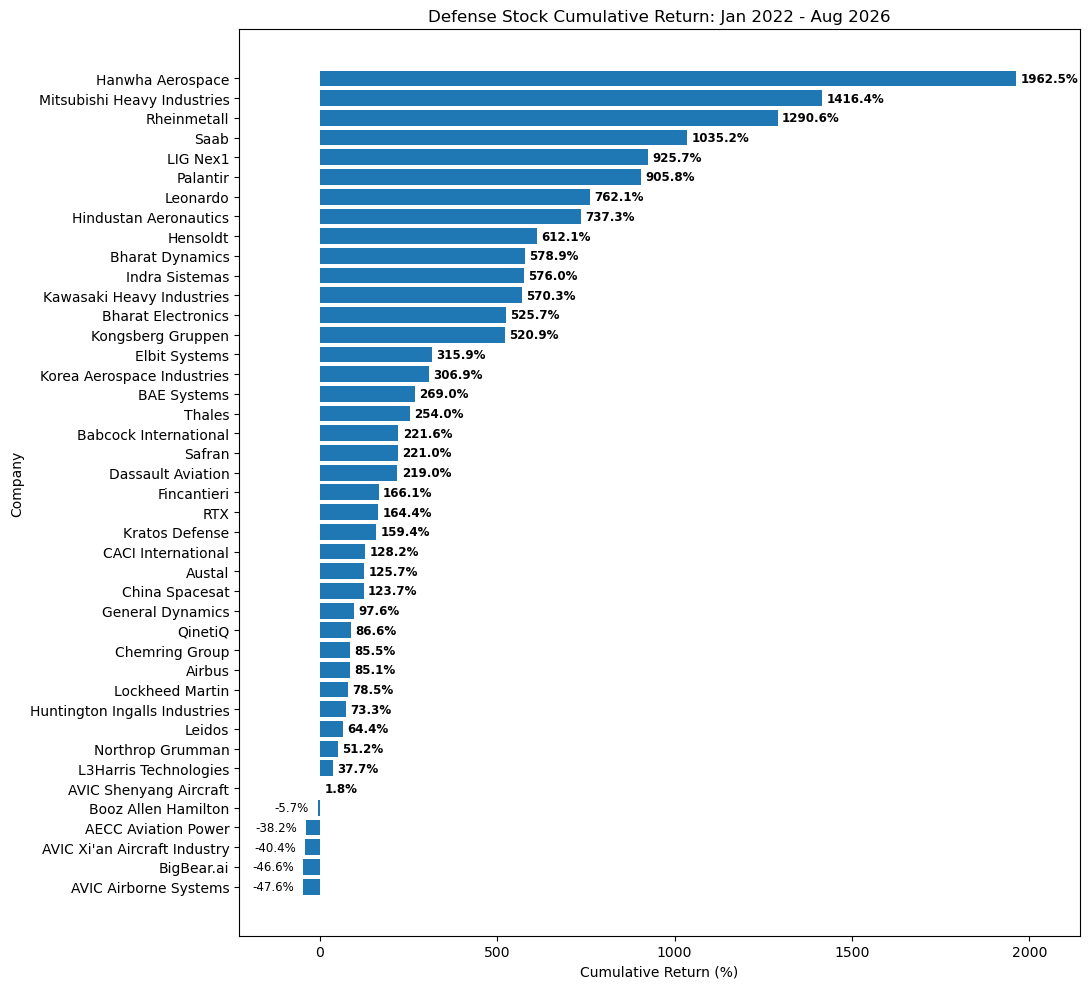

In [19]:
# Visualize cumulative stock return by company


plot_data = cumulative_returns.sort_values("Cumulative_Return_%")

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(
    plot_data["Company"],
    plot_data["Cumulative_Return_%"]
)

for bar, value in zip(bars, plot_data["Cumulative_Return_%"]):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 12,
            y,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=8.5,
            fontweight="semibold",
            color="black"
        )

    else:
        ax.text(
            value - 25,
            y,
            f"{value:.1f}%",
            va="center",
            ha="right",
            fontsize=8.5,
            fontweight="normal",
            color="black"
        )

ax.set_xlabel("Cumulative Return (%)")
ax.set_ylabel("Company")
ax.set_title("Defense Stock Cumulative Return: Jan 2022 - Aug 2026")

# More room on the left for negative values
ax.set_xlim(
    plot_data["Cumulative_Return_%"].min() - 180,
    plot_data["Cumulative_Return_%"].max() + 180
)

plt.tight_layout()
plt.show()


**Interpretation:**

The strongest cumulative returns based on adjusted closing prices in the sample were recorded by Hanwha Aerospace, Mitsubishi Heavy Industries, Rheinmetall, Saab, LIG Nex1 and Palantir. Several companies increased by more than 500%, while a small group recorded negative cumulative returns over the same period.

The wide dispersion shows that performance within the defense sector was highly uneven. The calculations use adjusted closing prices in each stock's local trading currency and are not adjusted for foreign-exchange movements.


## 10. Compare Cumulative Return by Defense Group

Which defense business type performed best?


In [20]:
# Merge cumulative returns with analysis group information
cumulative_returns_grouped = cumulative_returns.merge(
    company_metadata[
        [
            "Ticker",
            "Analysis_Group"
        ]
    ],
    on="Ticker",
    how="left"
)

# Calculate mean, median and number of companies by analysis group
type_returns = (
    cumulative_returns_grouped
    .groupby("Analysis_Group")["Cumulative_Return_%"]
    .agg(
        Average_Return="mean",
        Median_Return="median",
        Companies="count"
    )
)

# Round return values for cleaner display
type_returns["Average_Return"] = (
    type_returns["Average_Return"].round(1)
)

type_returns["Median_Return"] = (
    type_returns["Median_Return"].round(1)
)

# Sort by average cumulative return
type_returns = type_returns.sort_values(
    "Average_Return",
    ascending=False
)

# Display results
print(type_returns)


                                  Average_Return  Median_Return  Companies
Analysis_Group                                                            
Aerospace / Industrial Defense             437.3          221.0         17
Traditional Defense                        436.5          269.0         11
Defense Technology / Electronics           259.2          141.6          8
Defense Software / AI / Services           211.3           96.3          6


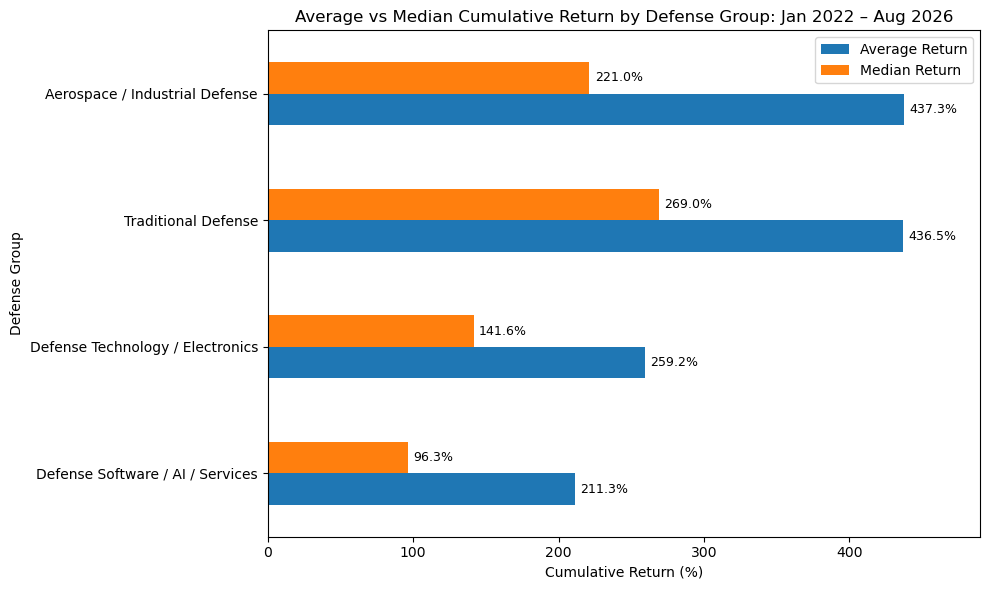

In [21]:
# Visualize average and median cumulative return by analysis group

plot_type = (
    type_returns[
        ["Average_Return", "Median_Return"]
    ]
    .sort_values("Average_Return")
)

ax = plot_type.plot(
    kind="barh",
    figsize=(10, 6)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" for v in container.datavalues],
        padding=4,
        fontsize=9
    )

# Add extra space on the right for the value labels
max_return = plot_type.to_numpy().max()

ax.set_xlim(
    0,
    max_return * 1.12
)

ax.set_xlabel("Cumulative Return (%)")
ax.set_ylabel("Defense Group")

ax.set_title(
    "Average vs Median Cumulative Return by Defense Group: Jan 2022 – Aug 2026"
)

ax.legend(
    ["Average Return", "Median Return"]
)

plt.tight_layout()
plt.show()


**Interpretation:**

Aerospace / Industrial Defense and Traditional Defense recorded the highest average cumulative returns in the sample, at 437.3% and 436.5% respectively.

However, the median returns show a different picture. Traditional Defense had the highest median return at 269.0%, followed by Aerospace / Industrial Defense at 221.0%. This indicates that the very high average return of the Aerospace / Industrial Defense group was influenced by a small number of exceptionally strong-performing companies.

Defense Technology / Electronics and Defense Software / AI / Services showed lower results using both the average and the median.

The comparison therefore suggests that Traditional Defense had the strongest typical company performance based on the median, while Aerospace / Industrial Defense had a similarly high average that was more strongly influenced by a small number of exceptionally high-performing companies.


## 11. Review Geographic Coverage

How geographically balanced is the company sample?


Country
United States     12
China              5
United Kingdom     4
South Korea        3
India              3
France             3
Germany            2
Italy              2
Japan              2
Sweden             1
Netherlands        1
Israel             1
Spain              1
Norway             1
Australia          1
Name: count, dtype: int64


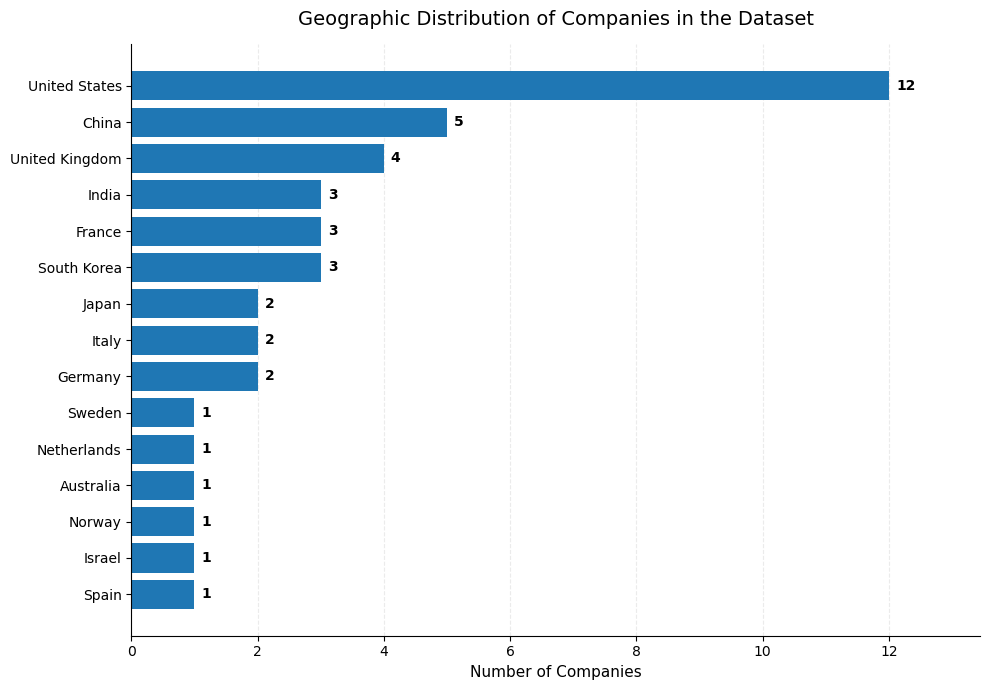

In [22]:
# Count companies by country
country_counts = (
    company_metadata["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

# Print company counts by country
print(country_counts)

# Sort for horizontal chart
plot_country_counts = country_counts.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_country_counts.index,
    plot_country_counts.values
)

# Add values at the end of each bar
ax.bar_label(
    bars,
    labels=[str(value) for value in plot_country_counts.values],
    padding=5,
    fontsize=10,
    fontweight="semibold"
)

# Labels and title
ax.set_xlabel("Number of Companies", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Geographic Distribution of Companies in the Dataset",
    fontsize=14,
    pad=14
)

# Light grid for easier comparison
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add extra space for labels
ax.set_xlim(
    0,
    plot_country_counts.max() * 1.12
)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()


In [23]:
# World map of company coverage by country


# Prepare data
map_data = (
    company_metadata["Country"]
    .value_counts()
    .rename_axis("Country")
    .reset_index(name="Number_of_Companies")
)

# Create categories so countries with few companies remain visible
map_data["Company_Range"] = pd.cut(
    map_data["Number_of_Companies"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=[
        "1 company",
        "2–3 companies",
        "4–5 companies",
        "6–10 companies",
        "11+ companies"
    ]
)

# Create map
fig = px.choropleth(
    map_data,
    locations="Country",
    locationmode="country names",
    color="Company_Range",
    hover_name="Country",
    hover_data={
        "Number_of_Companies": True,
        "Company_Range": False
    },
    title="Global Coverage of Defense Companies in the Dataset",
    category_orders={
        "Company_Range": [
            "1 company",
            "2–3 companies",
            "4–5 companies",
            "6–10 companies",
            "11+ companies"
        ]
    }
)

# Improve appearance
fig.update_geos(
    showcoastlines=True,
    coastlinecolor="Gray",
    showland=True,
    landcolor="rgb(235, 235, 235)",
    showocean=True,
    oceancolor="rgb(248, 250, 252)",
    showcountries=True,
    countrycolor="White",
    projection_type="natural earth"
)

fig.update_layout(
    width=1200,
    height=650,
    margin=dict(l=20, r=20, t=70, b=20),

    title=dict(
        x=0.5,
        xanchor="center"
    ),

    legend_title_text="Companies"
)

fig.show()


/tmp/ipykernel_97151/200999688.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


**Interpretation:**

The sample is geographically diverse, but not evenly balanced. The United States is clearly the largest group with 12 companies, followed by China with 5 and the United Kingdom with 4, while several countries are represented by only one or two companies.

The map shows that the dataset covers major defense markets across North America, Europe and Asia, but the unequal number of companies per country means that the sample should not be used for direct country-performance rankings without additional weighting or normalization.

Note: Airbus SE appears under the Netherlands because the company is legally registered there; the AIR.PA listing used in this analysis is traded in Paris.


## 12. Analyze Company Reactions Around Geopolitical Events

How did individual defense companies' stock prices react within a 10-trading-day window around major geopolitical events?


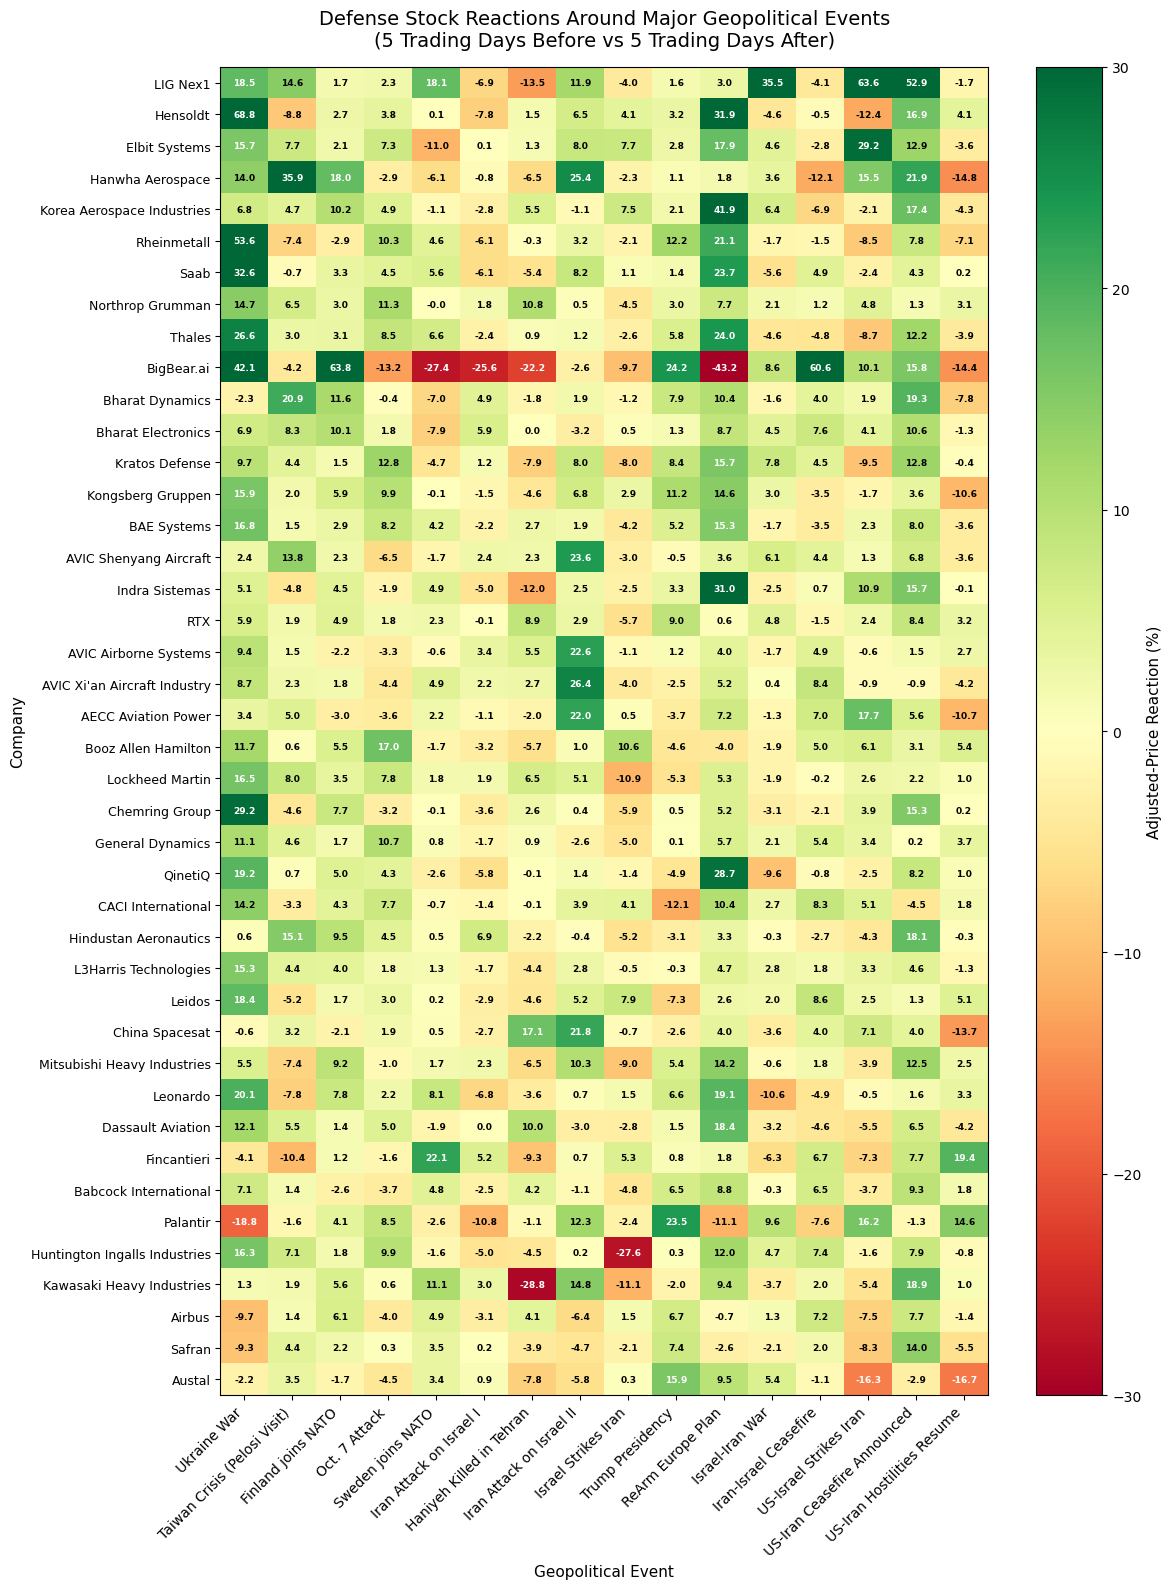

In [24]:

# Prepare data

# Make sure Date column is datetime
data["Date"] = pd.to_datetime(data["Date"])

# Sort data
data = data.sort_values(["Ticker", "Date"]).copy()


# Calculate stock-price reactions around each event

# 10-trading-day event window:
# 5 trading days before the event
# to 5 trading days after the event

event_reactions = []

for ticker, company_data in data.groupby("Ticker"):

    company_data = (
        company_data
        .sort_values("Date")
        .reset_index(drop=True)
        .copy()
    )

    # Loop over all centrally defined geopolitical events
    for event_name, event_date in events.items():

        event_date = pd.to_datetime(event_date)

        # Find nearest available trading day to the event date
        nearest_idx = (
            company_data["Date"] - event_date
        ).abs().idxmin()

        # Need at least 5 trading days before
        # and 5 trading days after the event
        if nearest_idx >= 5 and nearest_idx + 5 < len(company_data):

            # Closing price 5 trading days before the event
            price_before = company_data.loc[
                nearest_idx - 5,
                "Close"
            ]

            # Closing price 5 trading days after the event
            price_after = company_data.loc[
                nearest_idx + 5,
                "Close"
            ]

            # Calculate percentage price reaction
            reaction_pct = (
                price_after / price_before - 1
            ) * 100

            event_reactions.append({
                "Ticker": ticker,
                "Company": company_data.loc[
                    nearest_idx,
                    "Company"
                ],
                "Country": company_data.loc[
                    nearest_idx,
                    "Country"
                ],
                "Event": event_name,
                "Reaction_10D_%": reaction_pct
            })


# Create DataFrame
event_reactions = pd.DataFrame(event_reactions)


# Create the heatmap table

heatmap_data = event_reactions.pivot_table(
    index="Company",
    columns="Event",
    values="Reaction_10D_%"
)

# Order companies by average reaction across all events
heatmap_data["Average_Reaction"] = (
    heatmap_data.mean(axis=1)
)

heatmap_data = heatmap_data.sort_values(
    "Average_Reaction",
    ascending=False
)

heatmap_data = heatmap_data.drop(
    columns="Average_Reaction"
)

# Keep event order exactly as defined
# in the central events dictionary
heatmap_data = heatmap_data[
    [
        event
        for event in events.keys()
        if event in heatmap_data.columns
    ]
]


# Plot the heatmap

fig, ax = plt.subplots(figsize=(12, 16))

# Color scale:
# red = negative
# yellow/light = neutral
# green = positive
image = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap=price_reaction_cmap,
    vmin=-30,
    vmax=30
)


# Configure axis labels

ax.set_xticks(
    np.arange(len(heatmap_data.columns))
)

ax.set_yticks(
    np.arange(len(heatmap_data.index))
)

ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

ax.set_yticklabels(
    heatmap_data.index,
    fontsize=9
)

ax.set_xlabel(
    "Geopolitical Event",
    fontsize=11
)

ax.set_ylabel(
    "Company",
    fontsize=11
)

ax.set_title(
    "Defense Stock Reactions Around Major Geopolitical Events\n"
    "(5 Trading Days Before vs 5 Trading Days After)",
    fontsize=14,
    pad=15
)


# Add values inside each cell

for i in range(len(heatmap_data.index)):

    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        if pd.notna(value):

            # White text on stronger colors,
            # black text on lighter colors
            text_color = (
                "white"
                if abs(value) >= 15
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=6.5,
                fontweight="semibold",
                color=text_color
            )


# Add the color scale

cbar = plt.colorbar(
    image,
    ax=ax
)

cbar.set_label(
    "Adjusted-Price Reaction (%)",
    fontsize=11
)


# Display the chart

plt.tight_layout()
plt.show()


**Interpretation:**

The heatmap shows that stock-price reactions around geopolitical events differed strongly across companies and events. The largest positive reactions were concentrated in a smaller group of firms, while many companies showed only moderate changes or even negative reactions during the same event windows.

The strongest reactions were especially visible around the Ukraine War and several later security-related events. These results measure the price change from 5 trading days before to 5 trading days after each event and therefore show short-term market reactions rather than proof that the event itself caused the price movement.


## 13. Analyze Defense-Sector Performance Around Geopolitical Events

How did the global defense sector perform around major geopolitical events?


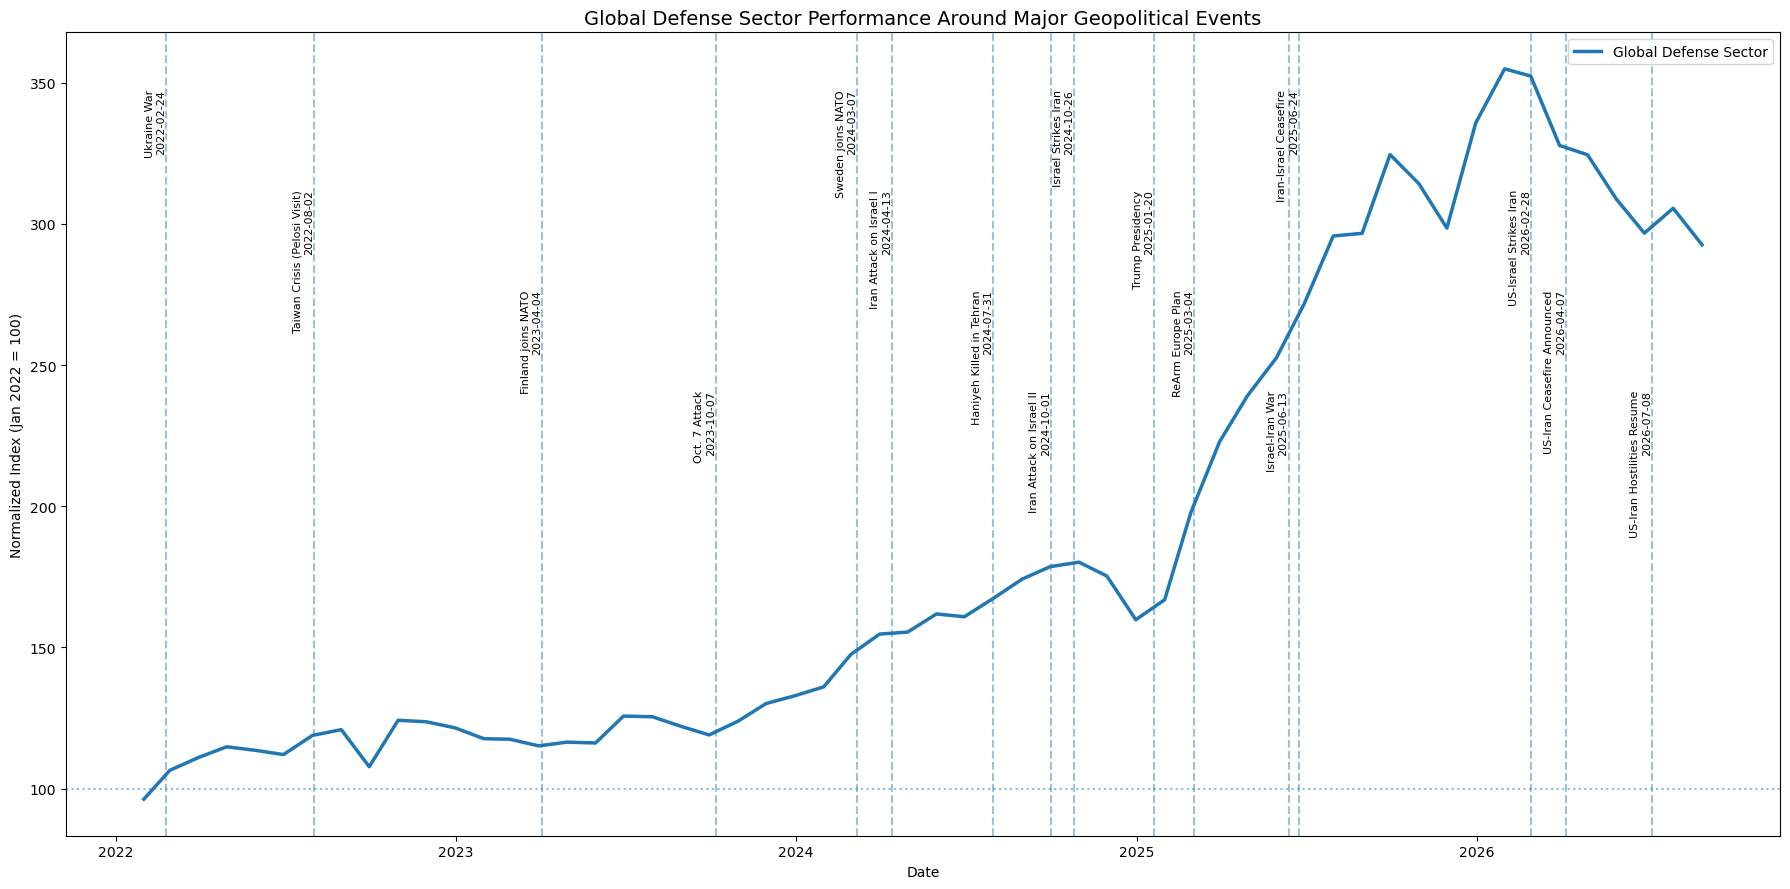

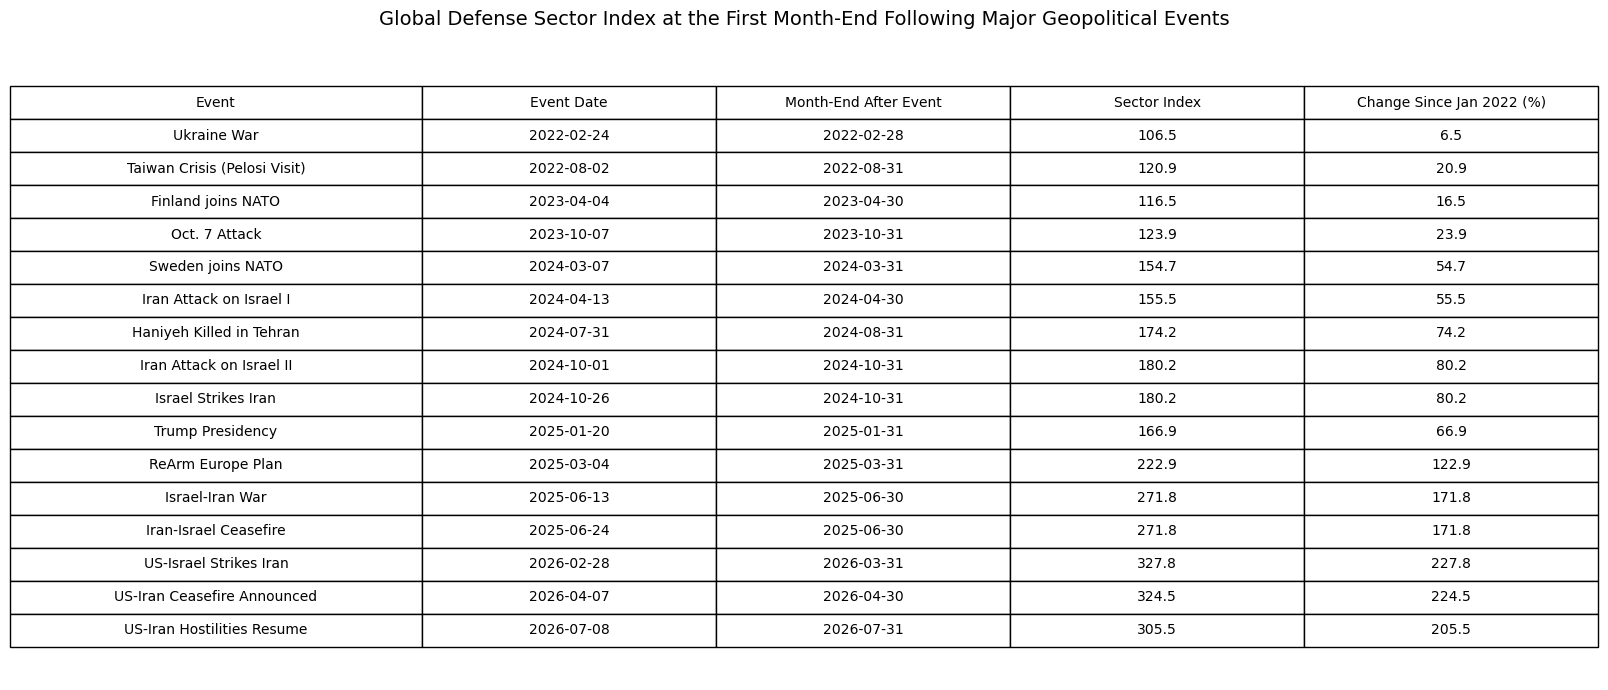

In [25]:
# Make sure Date is datetime
data["Date"] = pd.to_datetime(data["Date"])

# Sort data
sector_data = data.sort_values(["Ticker", "Date"]).copy()

# Normalize each company to 100 at the beginning of the analysis period
sector_data["Index_100"] = (
    sector_data.groupby("Ticker")["Close"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Convert daily data to monthly values to reduce noise
monthly_company = (
    sector_data
    .set_index("Date")
    .groupby("Ticker")["Index_100"]
    .resample("ME")
    .last()
    .reset_index()
)

# Median of all companies = overall global defense sector index
defense_sector = (
    monthly_company
    .groupby("Date")["Index_100"]
    .median()
)


# Plot the global defense-sector index
fig, ax = plt.subplots(figsize=(18, 9))

ax.plot(
    defense_sector.index,
    defense_sector.values,
    linewidth=2.5,
    label="Global Defense Sector"
)

# Baseline
ax.axhline(
    100,
    linestyle=":",
    alpha=0.5
)

# Different vertical positions to reduce label overlap
y_max = defense_sector.max()

label_levels = [
    y_max * 0.98,
    y_max * 0.88,
    y_max * 0.78,
    y_max * 0.68
]

# Add event lines and labels
for i, (label, date) in enumerate(events.items()):

    event_date = pd.to_datetime(date)

    ax.axvline(
        event_date,
        linestyle="--",
        alpha=0.45
    )

    y_position = label_levels[i % len(label_levels)]

    ax.text(
        event_date,
        y_position,
        f"{label}\n{event_date.strftime('%Y-%m-%d')}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=8
    )

ax.set_title(
    "Global Defense Sector Performance Around Major Geopolitical Events",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Index (Jan 2022 = 100)")
ax.legend()

plt.tight_layout()
plt.show()


# Build the event values table
event_results = []

for event, date in events.items():

    event_date = pd.to_datetime(date)

    # Find the first month-end observation strictly after the event
    position = defense_sector.index.searchsorted(
        event_date,
        side="right"
    )

    # Skip the event if no later month-end observation is available
    if position >= len(defense_sector):
        continue

    month_end_date = defense_sector.index[position]
    sector_value = defense_sector.iloc[position]

    event_results.append({
        "Event": event,
        "Event Date": event_date.strftime("%Y-%m-%d"),
        "Month-End After Event": month_end_date.strftime("%Y-%m-%d"),
        "Sector Index": round(sector_value, 1),
        "Change Since Jan 2022 (%)": round(sector_value - 100, 1)
    })

event_table = pd.DataFrame(event_results)


# Display the event values table
fig, ax = plt.subplots(figsize=(16, 7))

ax.axis("off")

table = ax.table(
    cellText=event_table.values,
    colLabels=event_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.7)

# Make event-name column wider
for row in range(len(event_table) + 1):
    table[(row, 0)].set_width(0.28)

plt.title(
    "Global Defense Sector Index at the First Month-End Following Major Geopolitical Events",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()


**Interpretation:**

The custom defense-sector index shows a clear long-term upward trend, with particularly strong acceleration from 2024 into 2025. The index reached 222.9 at the end of March 2025 and 271.8 by the end of June 2025, around 172% above its January 2022 baseline.

The index reached its highest monthly level at about 355 in January 2026 and later declined to about 293 by the end of August 2026.

The event table reports the first available month-end sector value strictly after each geopolitical event. These values provide medium-term context and should not be interpreted as immediate event-day reactions or evidence that the geopolitical events caused the observed market movements.

The sector index is a sample-based median of normalized company prices and is not a market-cap-weighted or investable index.


## 14. Analyze Annualized Volatility

Which defense companies had the highest annualized return volatility?


In [26]:
# Calculate daily returns for each company
volatility_data = data.sort_values(["Ticker", "Date"]).copy()

volatility_data["Daily_Return"] = (
    volatility_data
    .groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
)

# Calculate annualized volatility
volatility = (
    volatility_data
    .groupby(["Ticker", "Company", "Country"])["Daily_Return"]
    .std()
    * (252 ** 0.5)
    * 100
)

# Create clean volatility table
volatility = (
    volatility
    .reset_index(name="Annualized_Volatility_%")
    .sort_values(
        "Annualized_Volatility_%",
        ascending=False
    )
    .reset_index(drop=True)
)

# Create clean output table
volatility_table = volatility[
    [
        "Company",
        "Country",
        "Annualized_Volatility_%"
    ]
].copy()

# Round values for display
volatility_table["Annualized_Volatility_%"] = (
    volatility_table["Annualized_Volatility_%"].round(1)
)

# Display clean table
display(volatility_table)


,Company,Country,Annualized_Volatility_%
0,BigBear.ai,United States,171.6
1,Palantir,United States,68.2
2,LIG Nex1,South Korea,64.1
3,Hanwha Aerospace,South Korea,58.0
4,Kratos Defense,United States,54.2
5,Hensoldt,Germany,53.2
6,Austal,Australia,49.4
7,Korea Aerospace Industries,South Korea,48.9
8,Kawasaki Heavy Industries,Japan,47.0
9,China Spacesat,China,46.3


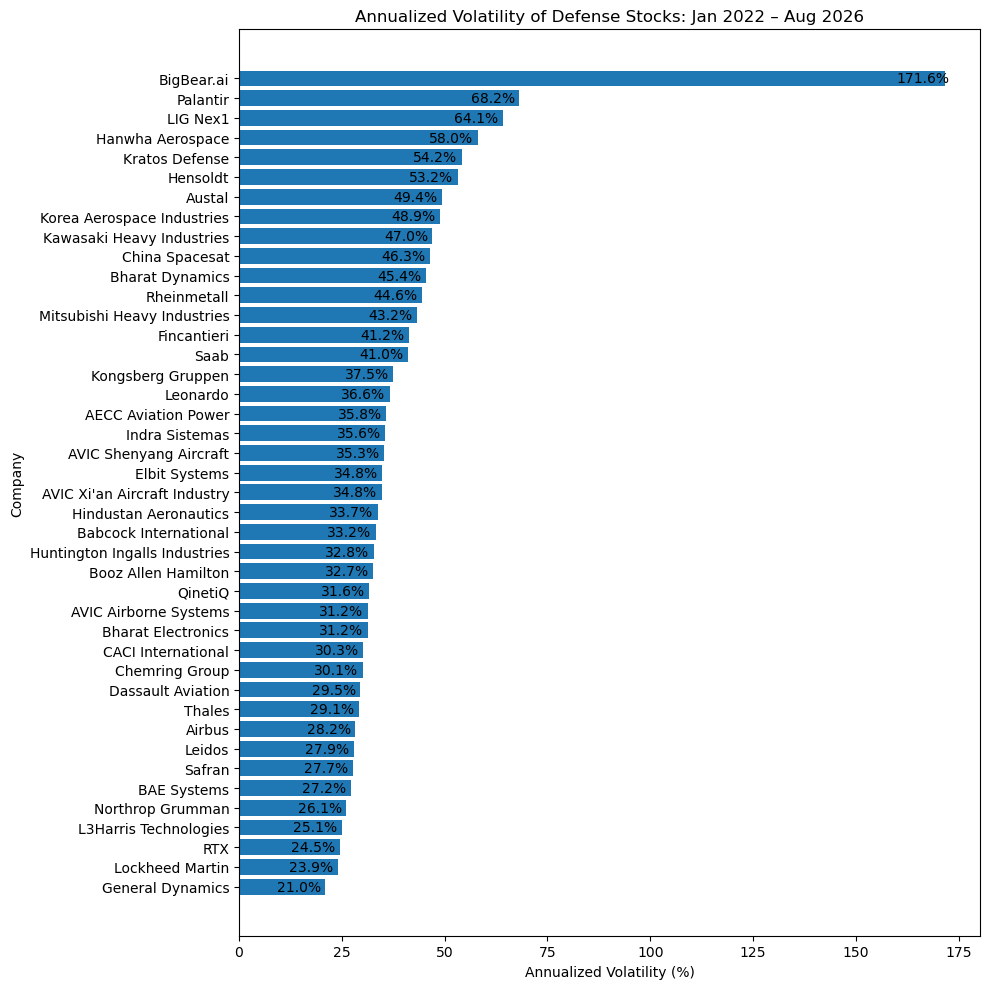

In [27]:
# Visualize annualized volatility by company

plot_volatility = volatility.sort_values(
    "Annualized_Volatility_%",
    ascending=True
)

plt.figure(figsize=(10, 10))

bars = plt.barh(
    plot_volatility["Company"],
    plot_volatility["Annualized_Volatility_%"]
)

# Show volatility values inside the bars
plt.bar_label(
    bars,
    labels=[f"{v:.1f}%" for v in plot_volatility["Annualized_Volatility_%"]],
    padding=-35
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Company")
plt.title("Annualized Volatility of Defense Stocks: Jan 2022 – Aug 2026")
plt.tight_layout()
plt.show()


**Interpretation:**

BigBear.ai showed by far the highest annualized volatility in the sample at about 172%, followed by Palantir, LIG Nex1, Hanwha Aerospace, Kratos Defense and Hensoldt.

The results show substantial differences in risk across the sample. More established defense contractors such as General Dynamics, Lockheed Martin and RTX were among the least volatile stocks, while several smaller or more growth-oriented companies experienced much larger price fluctuations.

High volatility does not necessarily imply poor performance; it indicates greater variation in daily stock returns.


## 15. Compare Return Relative to Volatility

Which defense companies had the highest return relative to their volatility?


In [28]:
# Merge cumulative return and volatility data
risk_return = cumulative_returns.merge(
    volatility[
        [
            "Ticker",
            "Annualized_Volatility_%"
        ]
    ],
    on="Ticker",
    how="left"
)

# Calculate length of the study period in years
years = (
    (data["Date"].max() - data["Date"].min()).days
    / 365.25
)

# Calculate annualized return
risk_return["Annualized_Return_%"] = (
    (
        1 + risk_return["Cumulative_Return_%"] / 100
    ) ** (1 / years)
    - 1
) * 100

# Calculate simple return-to-risk ratio
risk_return["Return_to_Risk"] = (
    risk_return["Annualized_Return_%"]
    / risk_return["Annualized_Volatility_%"]
)

# Sort from highest to lowest
risk_return = (
    risk_return
    .sort_values(
        "Return_to_Risk",
        ascending=False
    )
    .reset_index(drop=True)
)

# Create clean output table
risk_return_table = risk_return[
    [
        "Company",
        "Country",
        "Annualized_Return_%",
        "Annualized_Volatility_%",
        "Return_to_Risk"
    ]
].copy()

# Round values for display
risk_return_table["Annualized_Return_%"] = (
    risk_return_table["Annualized_Return_%"].round(1)
)

risk_return_table["Annualized_Volatility_%"] = (
    risk_return_table["Annualized_Volatility_%"].round(1)
)

risk_return_table["Return_to_Risk"] = (
    risk_return_table["Return_to_Risk"].round(2)
)

# Display clean table
display(risk_return_table)


,Company,Country,Annualized_Return_%,Annualized_Volatility_%,Return_to_Risk
0,Mitsubishi Heavy Industries,Japan,79.3,43.2,1.83
1,Hindustan Aeronautics,India,57.8,33.7,1.71
2,Rheinmetall,Germany,76.0,44.6,1.71
3,Saab,Sweden,68.5,41.0,1.67
4,Leonardo,Italy,58.8,36.6,1.61
5,Hanwha Aerospace,South Korea,91.5,58.0,1.58
6,Bharat Electronics,India,48.3,31.2,1.54
7,Indra Sistemas,Spain,50.7,35.6,1.43
8,Kongsberg Gruppen,Norway,48.0,37.5,1.28
9,BAE Systems,United Kingdom,32.4,27.2,1.19


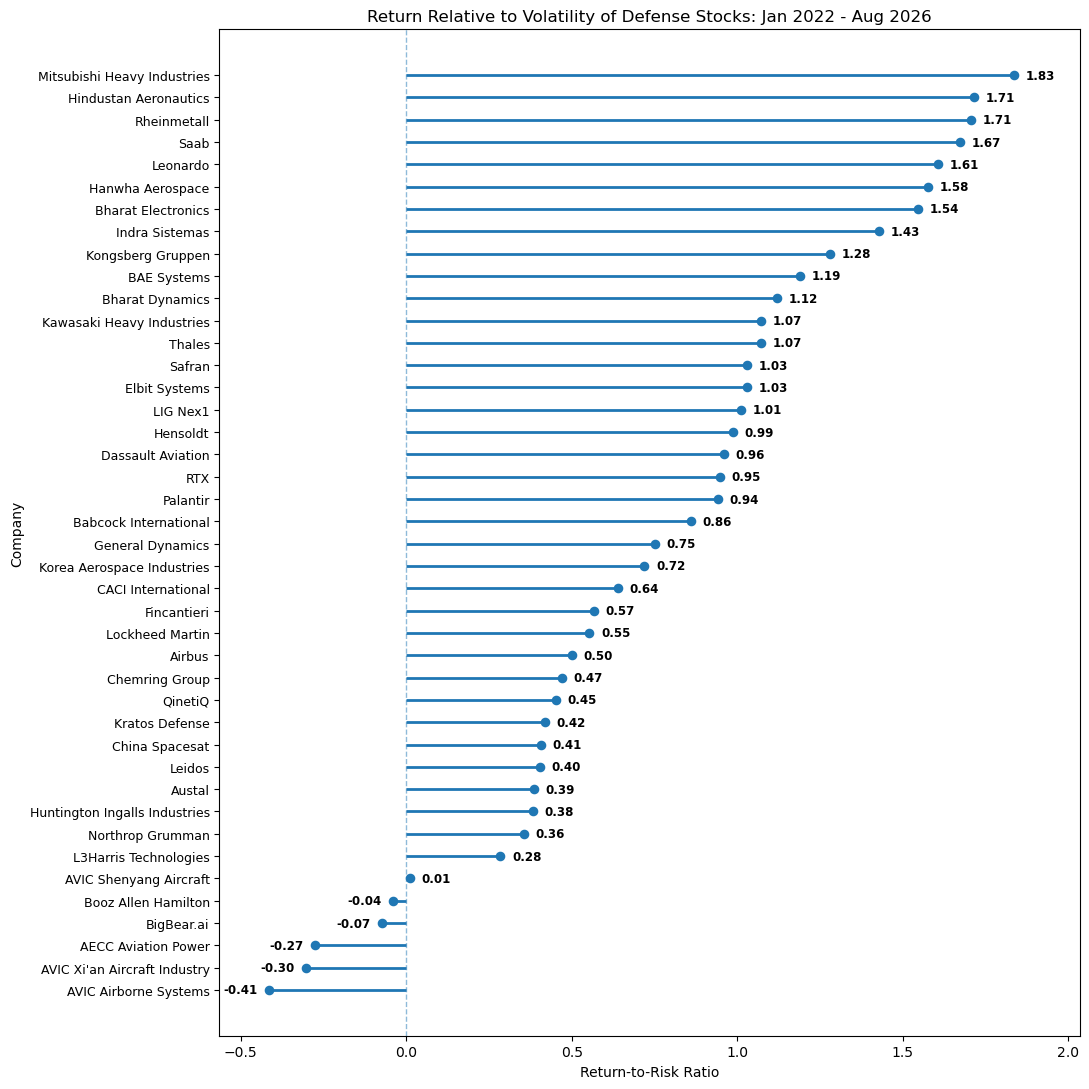

In [29]:
# Visualize return relative to volatility
# Sort from lowest to highest
plot_risk = risk_return.sort_values(
    "Return_to_Risk",
    ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 11))

y = range(len(plot_risk))

# Lines from zero to each value
ax.hlines(
    y=y,
    xmin=0,
    xmax=plot_risk["Return_to_Risk"],
    linewidth=2
)

# Points at the actual values
ax.scatter(
    plot_risk["Return_to_Risk"],
    y,
    s=35,
    zorder=3
)

# Company names
ax.set_yticks(y)
ax.set_yticklabels(
    plot_risk["Company"],
    fontsize=9
)

# Add values directly beside each point
for i, value in enumerate(plot_risk["Return_to_Risk"]):

    if value >= 0:
        ax.text(
            value + 0.035,
            i,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=8.5,
            fontweight="semibold"
        )
    else:
        ax.text(
            value - 0.035,
            i,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=8.5,
            fontweight="semibold"
        )

# Zero reference line
ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.set_xlabel("Return-to-Risk Ratio")
ax.set_ylabel("Company")

ax.set_title(
    "Return Relative to Volatility of Defense Stocks: Jan 2022 - Aug 2026"
)

ax.set_xlim(
    plot_risk["Return_to_Risk"].min() - 0.15,
    plot_risk["Return_to_Risk"].max() + 0.20
)

plt.tight_layout()
plt.show()


**Interpretation:**

Mitsubishi Heavy Industries achieved the highest return relative to volatility in the sample, followed by Hindustan Aeronautics, Rheinmetall, Saab, Leonardo and Hanwha Aerospace.

The ranking shows that some companies combined strong annualized returns with comparatively moderate volatility, while others generated high returns only with much larger price fluctuations. The `Return_to_Risk` measure used here is a simplified ratio of annualized return to annualized volatility and should not be interpreted as a Sharpe ratio because no risk-free rate is included.


## 16. Identify the Strongest Company Reactions

Which defense companies reacted most strongly around major geopolitical events?


In [30]:
# Top 10 companies based on their strongest positive event reaction

# Find the strongest event reaction for each company
strongest_reaction_per_company = (
    event_reactions
    .sort_values("Reaction_10D_%", ascending=False)
    .drop_duplicates(subset="Company", keep="first")
)

# Select the 10 companies with the strongest reactions
top_10_reactions = (
    strongest_reaction_per_company
    .head(10)
    .copy()
)

# Round values for cleaner display
top_10_reactions["Reaction_10D_%"] = (
    top_10_reactions["Reaction_10D_%"].round(1)
)

# Select columns
top_10_table = top_10_reactions[
    [
        "Event",
        "Company",
        "Country",
        "Reaction_10D_%"
    ]
]

# Display as a clean table in Jupyter
top_10_table = top_10_table.reset_index(drop=True)
display(top_10_table)


,Event,Company,Country,Reaction_10D_%
0,Ukraine War,Hensoldt,Germany,68.8
1,Finland joins NATO,BigBear.ai,United States,63.8
2,US-Israel Strikes Iran,LIG Nex1,South Korea,63.6
3,Ukraine War,Rheinmetall,Germany,53.6
4,ReArm Europe Plan,Korea Aerospace Industries,South Korea,41.9
5,Taiwan Crisis (Pelosi Visit),Hanwha Aerospace,South Korea,35.9
6,Ukraine War,Saab,Sweden,32.6
7,ReArm Europe Plan,Indra Sistemas,Spain,31.0
8,Ukraine War,Chemring Group,United Kingdom,29.2
9,US-Israel Strikes Iran,Elbit Systems,Israel,29.2


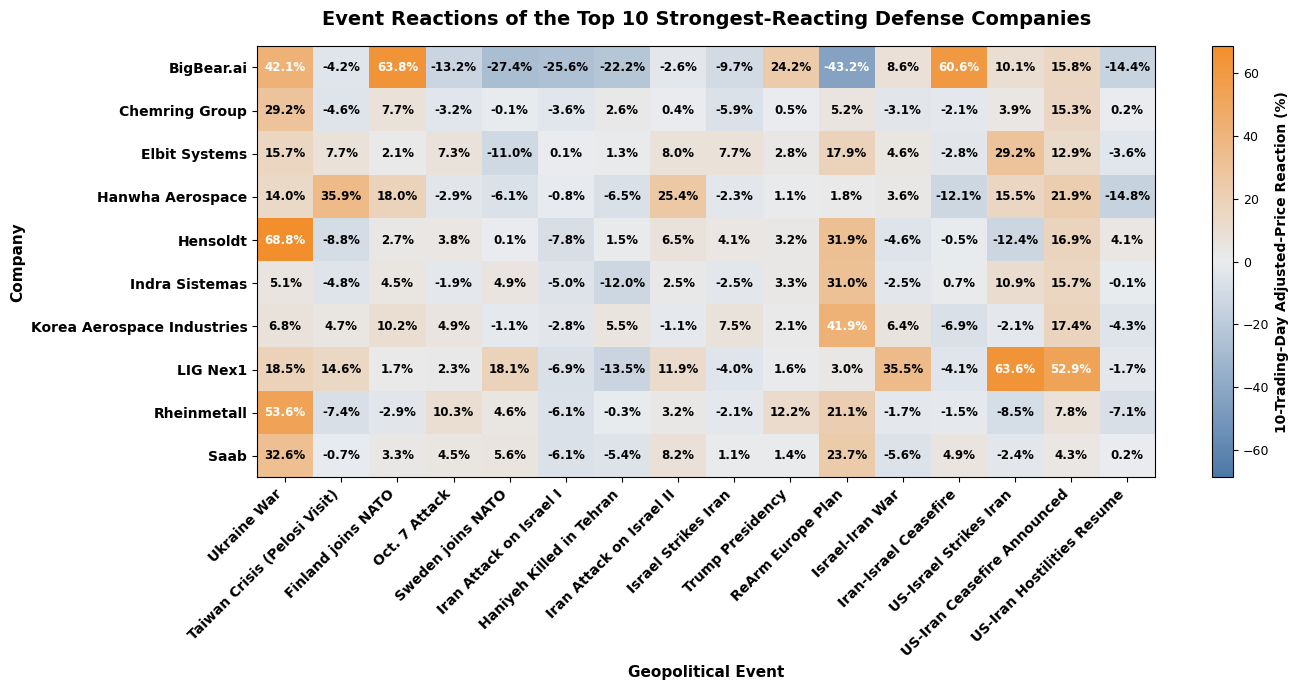

In [31]:
# Heatmap for Top 10 strongest-reacting companies
# Neutral colors with stronger, clearer text


# Get Top 10 companies
top_10_companies = top_10_table["Company"].tolist()

# Create heatmap data
top_10_heatmap = (
    event_reactions[
        event_reactions["Company"].isin(top_10_companies)
    ]
    .pivot(
        index="Company",
        columns="Event",
        values="Reaction_10D_%"
    )
)

# Keep event order
top_10_heatmap = top_10_heatmap[
    [event for event in events.keys() if event in top_10_heatmap.columns]
]

# Center color scale at zero and use the full observed reaction range
max_abs_reaction = np.nanmax(
    np.abs(top_10_heatmap.values)
)

norm = TwoSlopeNorm(
    vmin=-max_abs_reaction,
    vcenter=0,
    vmax=max_abs_reaction
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

image = ax.imshow(
    top_10_heatmap.values,
    aspect="auto",
    cmap=neutral_cmap,
    norm=norm
)

# X-axis labels
ax.set_xticks(range(len(top_10_heatmap.columns)))
ax.set_xticklabels(
    top_10_heatmap.columns,
    rotation=45,
    ha="right",
    fontsize=10,
    fontweight="semibold",
    color="black"
)

# Y-axis labels
ax.set_yticks(range(len(top_10_heatmap.index)))
ax.set_yticklabels(
    top_10_heatmap.index,
    fontsize=10,
    fontweight="semibold",
    color="black"
)

# Add values inside cells
for i in range(len(top_10_heatmap.index)):
    for j in range(len(top_10_heatmap.columns)):

        value = top_10_heatmap.iloc[i, j]

        if pd.notna(value):

            # White text on darker cells
            text_color = (
                "white"
                if abs(value) >= 0.55 * max_abs_reaction
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color=text_color
            )

# Color bar
cbar = plt.colorbar(image, ax=ax)

cbar.set_label(
    "10-Trading-Day Adjusted-Price Reaction (%)",
    fontsize=10,
    fontweight="semibold",
    color="black"
)

cbar.ax.tick_params(
    labelsize=9,
    colors="black"
)

# Title
ax.set_title(
    "Event Reactions of the Top 10 Strongest-Reacting Defense Companies",
    fontsize=14,
    fontweight="semibold",
    color="black",
    pad=15
)

# Axis titles
ax.set_xlabel(
    "Geopolitical Event",
    fontsize=11,
    fontweight="semibold",
    color="black"
)

ax.set_ylabel(
    "Company",
    fontsize=11,
    fontweight="semibold",
    color="black"
)

plt.tight_layout()
plt.show()


**Interpretation:**

The strongest short-term positive reactions were concentrated in a relatively small group of companies. Hensoldt showed the largest individual reaction in the sample around the Ukraine War, followed by BigBear.ai around Finland's NATO accession and LIG Nex1 around the US-Israel strikes on Iran.

BigBear.ai's result should be interpreted with particular caution because the stock had already risen strongly before Finland formally joined NATO. The event-window result therefore shows a strong price movement around the event date, but not evidence that NATO accession itself caused the increase.

The heatmap also shows that the same companies did not react positively to every event. Reactions varied considerably across events, suggesting that geopolitical developments affected companies differently depending on their market exposure, business profile and investor expectations.

The values represent price changes from 5 trading days before to 5 trading days after each event and therefore indicate short-term market reactions rather than causal effects.


## 17. Analyze Trading-Volume Reactions

Which defense companies had the strongest trading-volume spikes around major geopolitical events?


In [32]:
# Calculate trading-volume reactions around each geopolitical event
volume_reactions = []

for event, event_date in events.items():

    event_date = pd.to_datetime(event_date)

    for ticker, group in data.groupby("Ticker"):

        group = (
            group
            .sort_values("Date")
            .reset_index(drop=True)
            .copy()
        )

        # Find the trading day closest to the event date
        nearest_idx = (
            group["Date"] - event_date
        ).abs().idxmin()

        # Need at least 5 trading days before and after the event
        if nearest_idx >= 5 and nearest_idx + 5 < len(group):

            # Average trading volume during the 5 trading days before the event
            volume_before = group.loc[
                nearest_idx - 5:nearest_idx - 1,
                "Volume"
            ].mean()

            # Average trading volume during the 5 trading days after the event
            volume_after = group.loc[
                nearest_idx + 1:nearest_idx + 5,
                "Volume"
            ].mean()

            # Avoid division by zero
            if pd.notna(volume_before) and volume_before > 0:

                # Percentage change in average trading volume
                volume_change = (
                    volume_after / volume_before - 1
                ) * 100

                volume_reactions.append({
                    "Event": event,
                    "Ticker": ticker,
                    "Company": group.loc[nearest_idx, "Company"],
                    "Country": group.loc[nearest_idx, "Country"],
                    "Volume_Change_%": volume_change
                })

# Create DataFrame
volume_reactions = pd.DataFrame(volume_reactions)

# Top 20 strongest volume spikes
top_volume_spikes = (
    volume_reactions
    .sort_values(
        "Volume_Change_%",
        ascending=False
    )
    .head(20)
    .copy()
)

# Round values for cleaner display
top_volume_spikes["Volume_Change_%"] = (
    top_volume_spikes["Volume_Change_%"].round(1)
)

# Create clean output table
top_volume_table = (
    top_volume_spikes[
        [
            "Event",
            "Company",
            "Country",
            "Volume_Change_%"
        ]
    ]
    .reset_index(drop=True)
)

# Display table
display(top_volume_table)


,Event,Company,Country,Volume_Change_%
0,Taiwan Crisis (Pelosi Visit),BigBear.ai,United States,1889.0
1,Ukraine War,Hensoldt,Germany,1583.2
2,Ukraine War,BigBear.ai,United States,1256.1
3,Ukraine War,Kongsberg Gruppen,Norway,695.3
4,US-Israel Strikes Iran,LIG Nex1,South Korea,664.9
5,Ukraine War,Fincantieri,Italy,611.3
6,Ukraine War,Rheinmetall,Germany,610.9
7,Ukraine War,Leonardo,Italy,576.8
8,Israel Strikes Iran,Huntington Ingalls Industries,United States,476.1
9,Ukraine War,Hanwha Aerospace,South Korea,339.3


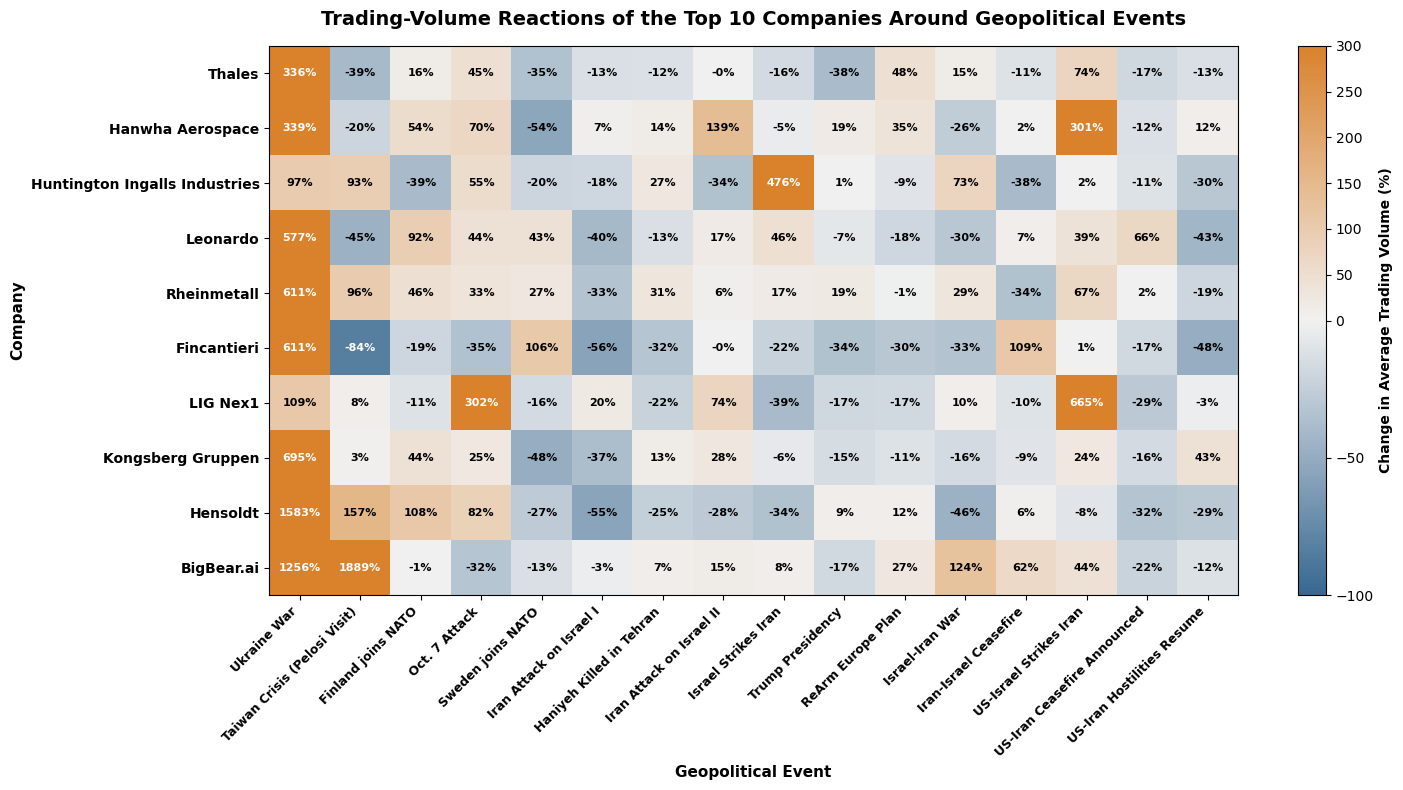

In [33]:
# Select the 10 companies with the strongest volume spikes
top_10_volume_companies = (
    volume_reactions
    .groupby("Company")["Volume_Change_%"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Create company-event matrix
volume_heatmap = (
    volume_reactions[
        volume_reactions["Company"].isin(top_10_volume_companies)
    ]
    .pivot(
        index="Company",
        columns="Event",
        values="Volume_Change_%"
    )
)

# Keep the existing event order
event_order = list(events.keys())

volume_heatmap = volume_heatmap[
    [event for event in event_order if event in volume_heatmap.columns]
]

# Sort companies by their strongest volume reaction
company_order = (
    volume_heatmap
    .max(axis=1)
    .sort_values(ascending=True)
    .index
)

volume_heatmap = volume_heatmap.loc[company_order]

# Keep extreme outliers from dominating the colors
norm = TwoSlopeNorm(
    vmin=-100,
    vcenter=0,
    vmax=300
)

# Create heatmap
fig, ax = plt.subplots(figsize=(15, 8))

image = ax.imshow(
    volume_heatmap.values,
    aspect="auto",
    cmap=volume_cmap,
    norm=norm
)

# Event labels
ax.set_xticks(range(len(volume_heatmap.columns)))
ax.set_xticklabels(
    volume_heatmap.columns,
    rotation=45,
    ha="right",
    fontsize=9,
    fontweight="semibold"
)

# Company labels
ax.set_yticks(range(len(volume_heatmap.index)))
ax.set_yticklabels(
    volume_heatmap.index,
    fontsize=10,
    fontweight="semibold"
)

# Show actual percentage values inside the cells
for i in range(len(volume_heatmap.index)):
    for j in range(len(volume_heatmap.columns)):

        value = volume_heatmap.iloc[i, j]

        if pd.notna(value):
            text_color = (
                "white"
                if value >= 180 or value <= -60
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="semibold",
                color=text_color
            )

# Add color scale
cbar = plt.colorbar(image, ax=ax)
cbar.set_label(
    "Change in Average Trading Volume (%)",
    fontsize=10,
    fontweight="semibold"
)

ax.set_title(
    "Trading-Volume Reactions of the Top 10 Companies Around Geopolitical Events",
    fontsize=14,
    fontweight="semibold",
    pad=15
)

ax.set_xlabel(
    "Geopolitical Event",
    fontsize=11,
    fontweight="semibold"
)

ax.set_ylabel(
    "Company",
    fontsize=11,
    fontweight="semibold"
)

plt.tight_layout()
plt.show()


**Interpretation:**

Trading-volume reactions were much more extreme than price reactions for several companies. BigBear.ai showed the largest volume spike around the Taiwan Crisis, while Hensoldt recorded an exceptionally strong increase around the Ukraine War.

The Ukraine War was associated with large trading-volume increases across several European defense companies, including Hensoldt, Kongsberg Gruppen, Fincantieri, Rheinmetall and Leonardo. This suggests a sharp rise in investor attention and trading activity around major geopolitical shocks.

The measure compares average trading volume during the 5 trading days before each event with the 5 trading days after it. Large percentage changes indicate unusually strong trading activity, but do not by themselves show whether investors were buying or selling.


## 18. Analyze Stock Correlations

Which defense stocks were most strongly correlated with each other?


,Company_1,Company_2,Correlation
0,AVIC Shenyang Aircraft,AVIC Xi'an Aircraft Industry,0.77
1,Dassault Aviation,Thales,0.75
2,AECC Aviation Power,AVIC Xi'an Aircraft Industry,0.75
3,Airbus,Safran,0.75
4,BAE Systems,Thales,0.72
5,Hensoldt,Rheinmetall,0.71
6,AVIC Airborne Systems,AVIC Xi'an Aircraft Industry,0.71
7,Leonardo,Thales,0.70
8,Bharat Electronics,Hindustan Aeronautics,0.70
9,BAE Systems,Leonardo,0.68


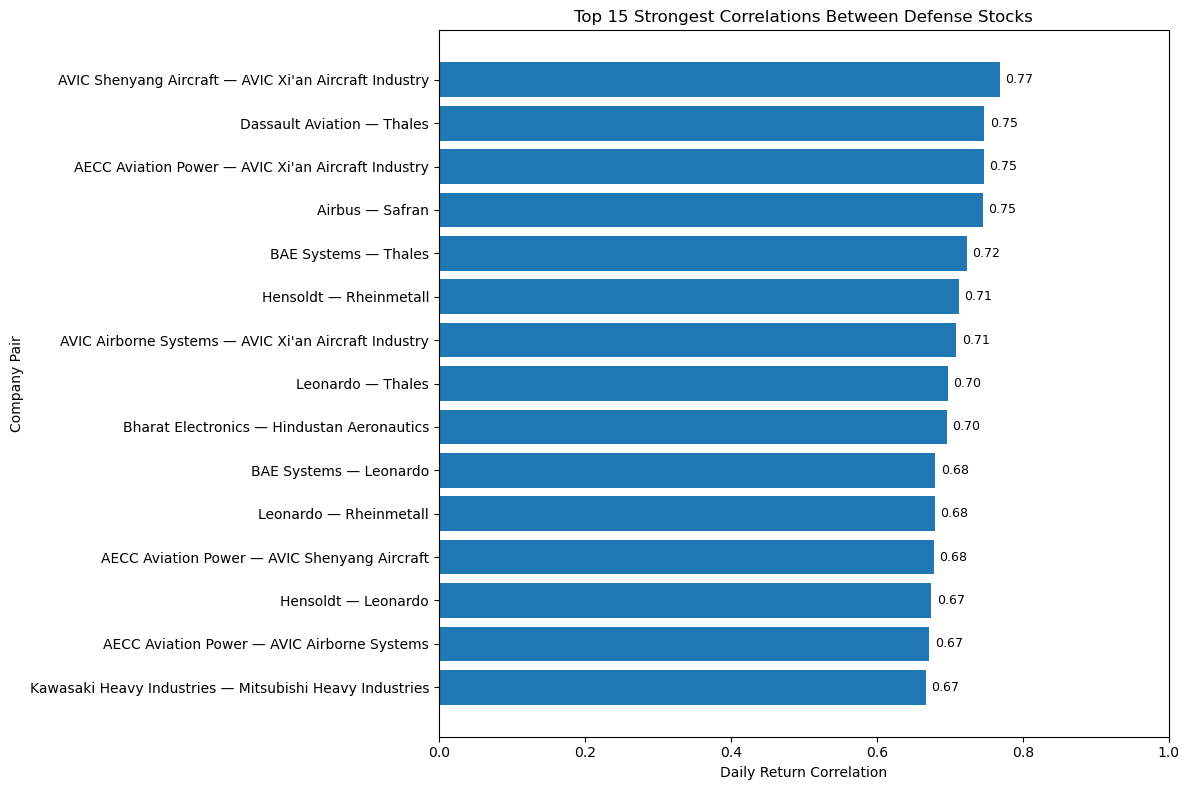

In [34]:
# Create a wide table from the already calculated daily returns
returns_wide = (
    data
    .pivot(
        index="Date",
        columns="Company",
        values="Daily_Return"
    )
)

# Calculate correlation matrix
correlation_matrix = returns_wide.corr()

# Keep each company pair only once
upper_triangle = np.triu(
    np.ones(correlation_matrix.shape),
    k=1
).astype(bool)

correlation_pairs = (
    correlation_matrix
    .where(upper_triangle)
    .rename_axis(
        index="Company_1",
        columns="Company_2"
    )
    .stack()
    .reset_index(name="Correlation")
)

# Top 20 strongest correlations
top_correlations = (
    correlation_pairs
    .sort_values("Correlation", ascending=False)
    .head(20)
    .copy()
)

# Round values for cleaner display
top_correlations["Correlation"] = (
    top_correlations["Correlation"].round(2)
)

# Clean table
top_correlations_table = (
    top_correlations[
        [
            "Company_1",
            "Company_2",
            "Correlation"
        ]
    ]
    .reset_index(drop=True)
)

# Display table
display(top_correlations_table)


# Create chart with the 15 strongest correlations
top_corr_plot = (
    correlation_pairs
    .sort_values("Correlation", ascending=False)
    .head(15)
    .copy()
)

# Combine company names for chart labels
top_corr_plot["Pair"] = (
    top_corr_plot["Company_1"]
    + " — "
    + top_corr_plot["Company_2"]
)

top_corr_plot = top_corr_plot.sort_values(
    "Correlation",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_corr_plot["Pair"],
    top_corr_plot["Correlation"]
)

# Show correlation values
ax.bar_label(
    bars,
    labels=[
        f"{v:.2f}"
        for v in top_corr_plot["Correlation"]
    ],
    padding=4,
    fontsize=9
)

ax.set_xlabel("Daily Return Correlation")
ax.set_ylabel("Company Pair")

ax.set_title(
    "Top 15 Strongest Correlations Between Defense Stocks"
)

ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


**Interpretation:**

The strongest correlations were mainly found between companies operating in similar regional or industrial environments. AVIC Shenyang Aircraft and AVIC Xi'an Aircraft Industry showed the highest correlation in the sample, followed by Dassault Aviation and Thales, AECC Aviation Power and AVIC Xi'an Aircraft Industry, Airbus and Safran, and BAE Systems and Thales.

Several European defense companies also moved relatively closely together, including Hensoldt and Rheinmetall as well as Leonardo and Thales. These correlations indicate similar daily return patterns, but they do not imply that one company's stock movement caused another's.


## 19. Measure Deviation from the Sector Trend

Which defense companies deviated most from the overall defense-sector trend?


In [35]:
# Calculate daily returns for each company
deviation_data = data.sort_values(["Ticker", "Date"]).copy()

deviation_data["Daily_Return"] = (
    deviation_data
    .groupby("Ticker")["Close"]
    .pct_change(fill_method=None)
)

# Calculate the median daily return of the whole defense sector
sector_daily = (
    deviation_data
    .groupby("Date")["Daily_Return"]
    .median()
    .rename("Sector_Return")
)

# Add sector return to each company observation
deviation_data = deviation_data.merge(
    sector_daily,
    on="Date",
    how="left"
)

# Calculate deviation from the sector
deviation_data["Deviation"] = (
    deviation_data["Daily_Return"]
    - deviation_data["Sector_Return"]
)

# Calculate average absolute daily deviation for each company
company_deviation = (
    deviation_data
    .groupby(["Ticker", "Company", "Country"])["Deviation"]
    .apply(lambda x: x.abs().mean())
    .reset_index(name="Average_Absolute_Deviation")
)

# Convert to percentage points
company_deviation["Average_Daily_Deviation_pp"] = (
    company_deviation["Average_Absolute_Deviation"] * 100
)

# Create clean table
deviation_table = (
    company_deviation[
        [
            "Company",
            "Country",
            "Average_Daily_Deviation_pp"
        ]
    ]
    .sort_values(
        "Average_Daily_Deviation_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

# Round values for display
deviation_table["Average_Daily_Deviation_pp"] = (
    deviation_table["Average_Daily_Deviation_pp"].round(2)
)

display(deviation_table)


,Company,Country,Average_Daily_Deviation_pp
0,BigBear.ai,United States,5.31
1,Palantir,United States,2.85
2,LIG Nex1,South Korea,2.58
3,Hanwha Aerospace,South Korea,2.46
4,Kratos Defense,United States,2.16
5,Kawasaki Heavy Industries,Japan,2.04
6,Korea Aerospace Industries,South Korea,2.03
7,Austal,Australia,2.00
8,Bharat Dynamics,India,1.98
9,China Spacesat,China,1.96


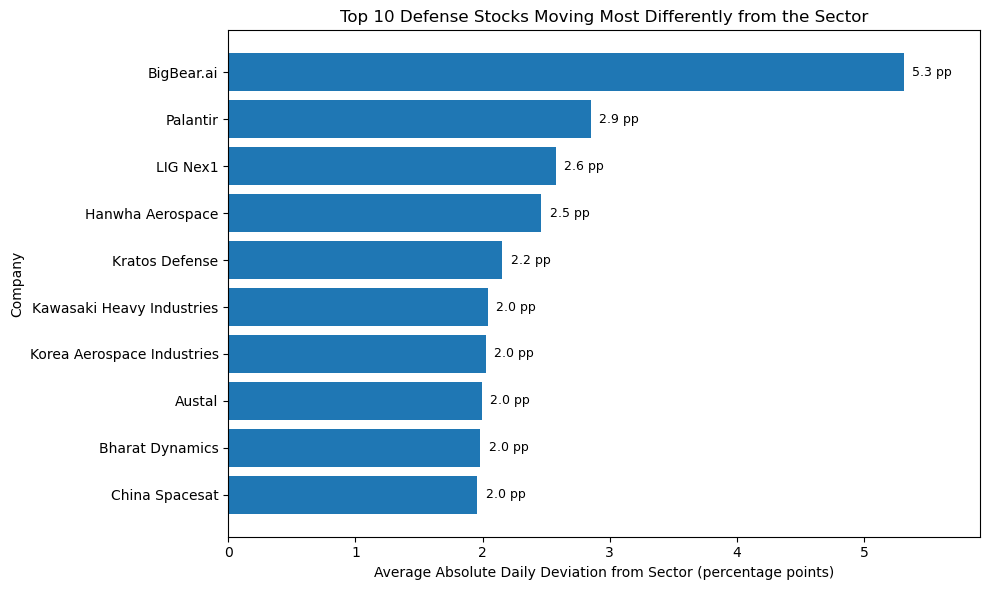

In [36]:
# Visualize the 10 companies that deviate most from the sector

top_deviation = (
    company_deviation
    .sort_values("Average_Daily_Deviation_pp", ascending=False)
    .head(10)
    .copy()
)

# Sort for horizontal bar chart
top_deviation = top_deviation.sort_values(
    "Average_Daily_Deviation_pp",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_deviation["Company"],
    top_deviation["Average_Daily_Deviation_pp"]
)

# Add values at the end of each bar
ax.bar_label(
    bars,
    labels=[
        f"{v:.1f} pp"
        for v in top_deviation["Average_Daily_Deviation_pp"]
    ],
    padding=6,
    fontsize=9
)

# Add extra space on the right
ax.set_xlim(
    0,
    top_deviation["Average_Daily_Deviation_pp"].max() + 0.6
)

ax.set_xlabel(
    "Average Absolute Daily Deviation from Sector (percentage points)"
)

ax.set_ylabel("Company")

ax.set_title(
    "Top 10 Defense Stocks Moving Most Differently from the Sector"
)

plt.tight_layout()
plt.show()


**Interpretation:**

BigBear.ai deviated most strongly from the overall defense-sector trend, with an average absolute daily deviation of about 5.3 percentage points. Palantir, LIG Nex1, Hanwha Aerospace and Kratos Defense also showed comparatively large deviations.

The results indicate that some companies moved much more independently from the broader defense-sector pattern, while large established contractors such as General Dynamics, Lockheed Martin and RTX remained closer to the sector's median daily return.

This measure captures the average absolute difference between each company's daily return and the median daily return of the defense-sector sample. It is therefore different from volatility: a stock can be volatile but still move broadly in line with the sector.


## 20. Compare the Defense Sector with Major Benchmarks

Did the global defense sector outperform major stock markets, gold and Brent oil from January 2022 to August 2026?


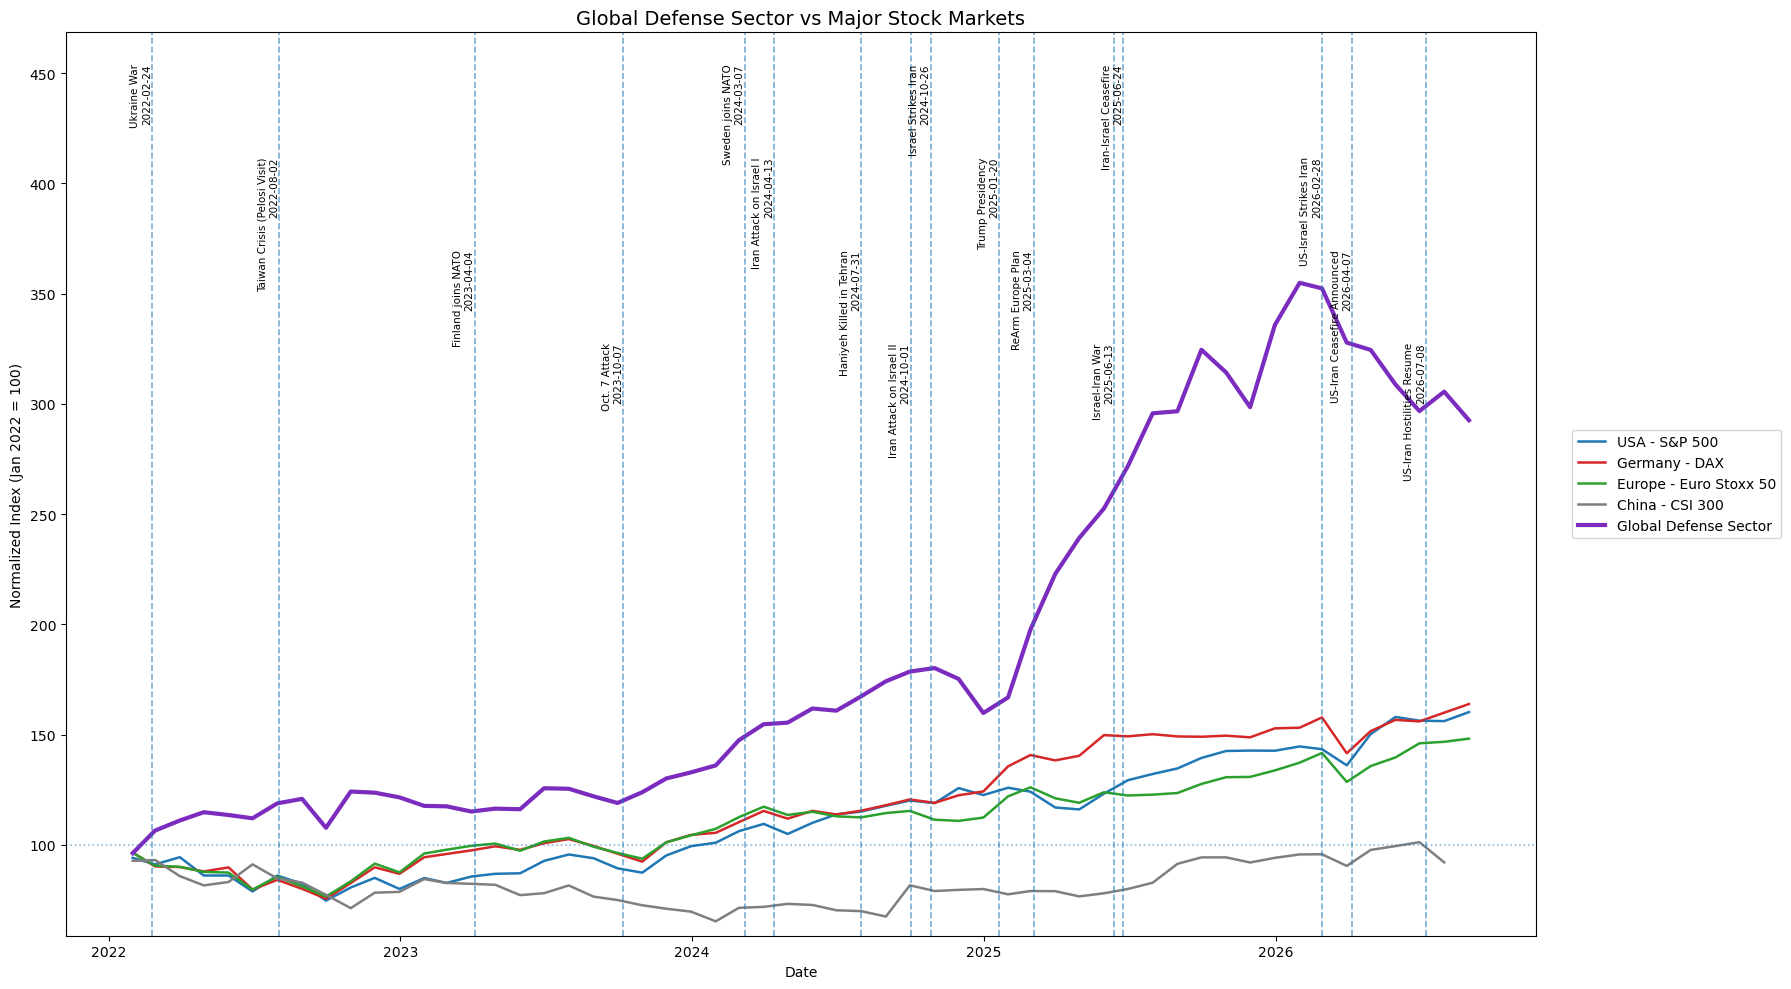

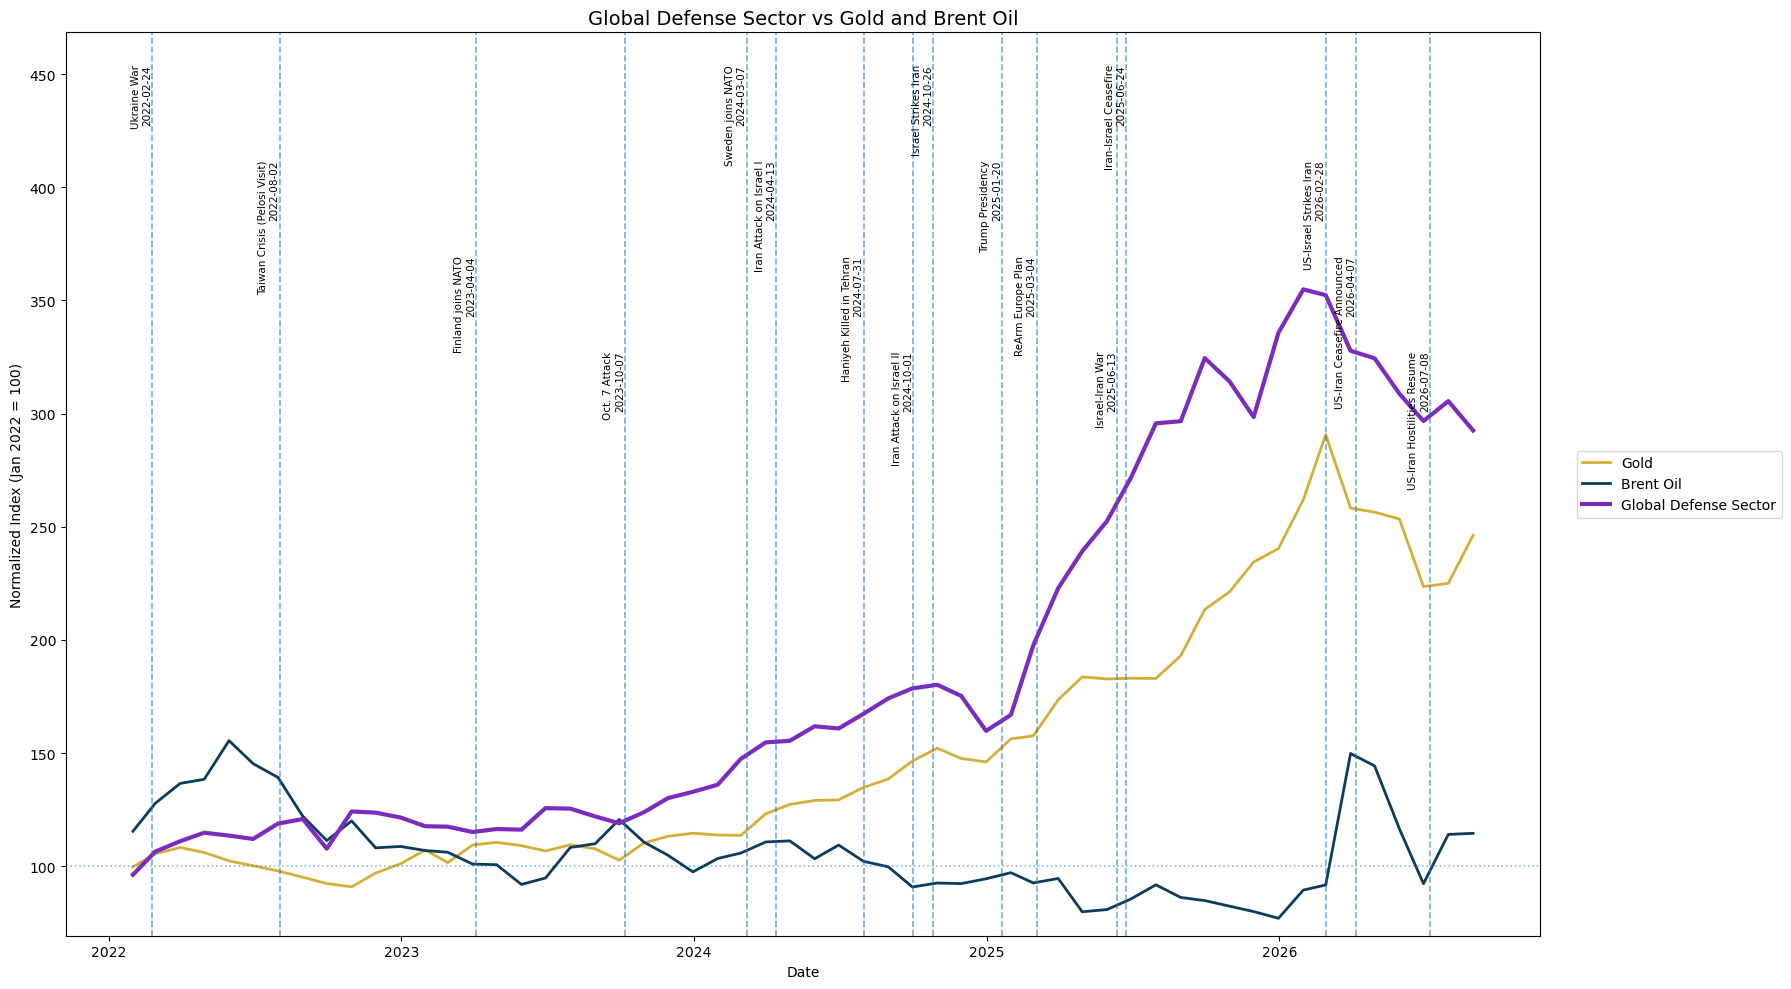

In [37]:
# Create the custom defense sector index
sector_data = data.sort_values(["Ticker", "Date"]).copy()

sector_data["Index_100"] = (
    sector_data.groupby("Ticker")["Close"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

monthly_company = (
    sector_data
    .set_index("Date")
    .groupby("Ticker")["Index_100"]
    .resample("ME")
    .last()
    .reset_index()
)

defense_sector = (
    monthly_company
    .groupby("Date")["Index_100"]
    .median()
)

# Normalize benchmarks to 100
benchmark_normalized = (
    benchmark_data
    / benchmark_data.apply(lambda x: x.dropna().iloc[0])
    * 100
)

benchmark_monthly = benchmark_normalized.resample("ME").last()

# Each company is already normalized to 100 at the beginning
# of the analysis period, so the sector index is not normalized again
defense_monthly = defense_sector.copy()

# Combine all series
comparison = benchmark_monthly.copy()
comparison["Global Defense Sector"] = defense_monthly

# Plot the defense sector against major stock markets

market_columns = [
    "USA - S&P 500",
    "Germany - DAX",
    "Europe - Euro Stoxx 50",
    "China - CSI 300",
    "Global Defense Sector"
]

fig, ax = plt.subplots(figsize=(18, 10))

for column in market_columns:
    ax.plot(
        comparison.index,
        comparison[column],
        linewidth=3 if column == "Global Defense Sector" else 1.8,
        color=market_colors[column],
        label=column
    )

# Baseline
ax.axhline(
    100,
    linestyle=":",
    linewidth=1.2,
    alpha=0.5
)

# Extra space for event labels
y_data_max = comparison[market_columns].max().max()
y_data_min = comparison[market_columns].min().min()

y_top = y_data_max * 1.32
y_bottom = y_data_min * 0.90

ax.set_ylim(y_bottom, y_top)

# Different positions for event labels
label_levels = [
    y_top * 0.97,
    y_top * 0.88,
    y_top * 0.79,
    y_top * 0.70
]

# Event lines and labels
for i, (label, date) in enumerate(events.items()):

    event_date = pd.to_datetime(date)

    ax.axvline(
        event_date,
        linestyle="--",
        linewidth=1.2,
        alpha=0.6
    )

    ax.text(
        event_date,
        label_levels[i % len(label_levels)],
        f"{label}\n{event_date.strftime('%Y-%m-%d')}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=7.5
    )

ax.set_title(
    "Global Defense Sector vs Major Stock Markets",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Index (Jan 2022 = 100)")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


# Plot the defense sector against gold and Brent oil

commodity_columns = [
    "Gold",
    "Brent Oil",
    "Global Defense Sector"
]

fig, ax = plt.subplots(figsize=(18, 10))

for column in commodity_columns:
    ax.plot(
        comparison.index,
        comparison[column],
        linewidth=3 if column == "Global Defense Sector" else 2,
        color=commodity_colors[column],
        label=column
    )

# Baseline
ax.axhline(
    100,
    linestyle=":",
    linewidth=1.2,
    alpha=0.5
)

# Extra space for event labels
y_data_max = comparison[commodity_columns].max().max()
y_data_min = comparison[commodity_columns].min().min()

y_top = y_data_max * 1.32
y_bottom = y_data_min * 0.90

ax.set_ylim(y_bottom, y_top)

label_levels = [
    y_top * 0.97,
    y_top * 0.88,
    y_top * 0.79,
    y_top * 0.70
]

# Event lines and labels
for i, (label, date) in enumerate(events.items()):

    event_date = pd.to_datetime(date)

    ax.axvline(
        event_date,
        linestyle="--",
        linewidth=1.2,
        alpha=0.6
    )

    ax.text(
        event_date,
        label_levels[i % len(label_levels)],
        f"{label}\n{event_date.strftime('%Y-%m-%d')}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=7.5
    )

ax.set_title(
    "Global Defense Sector vs Gold and Brent Oil",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized Index (Jan 2022 = 100)")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


**Interpretation:**

The custom global defense-sector index clearly outperformed the selected major stock-market benchmarks over the study period. Its normalized value rose above 350 in early 2026 and stood at about 293 at the end of August 2026, while the S&P 500, DAX and Euro Stoxx 50 remained much lower and the CSI 300 showed comparatively weak performance.

The defense-sector index also outperformed gold and Brent oil over the same period. Gold performed strongly, particularly from 2024 onward, while Brent oil remained much more volatile and ended far below the defense-sector index.

These comparisons are based on normalized index values and show relative performance within this sample. The defense-sector index is a custom median-based index of the selected companies and is not an official or investable market index.


## 21. Prepare and Export Data for Power BI

The following cells prepare a Power BI-ready analytical model. Python performs all calculations, while Power BI is used primarily for relationships, filtering and interactive visualization.

The model contains company and date dimensions together with prepared tables for daily stock prices, normalized market comparisons and geopolitical event reactions.


In [38]:
# Create the company dimension with prepared performance metrics
company_performance_columns = risk_return[
    [
        "Ticker",
        "Cumulative_Return_%",
        "Annualized_Return_%",
        "Annualized_Volatility_%",
        "Return_to_Risk"
    ]
].copy()

company_metadata_powerbi = company_metadata.merge(
    company_performance_columns,
    on="Ticker",
    how="left",
    validate="one_to_one"
)

# Create the daily stock-price fact table
stock_prices_powerbi = data[
    [
        "Date",
        "Ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Daily_Return"
    ]
].copy()

stock_prices_powerbi["Date"] = pd.to_datetime(
    stock_prices_powerbi["Date"]
).dt.normalize()

stock_prices_powerbi = stock_prices_powerbi.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

# Create the date dimension
date_table = pd.DataFrame({
    "Date": pd.date_range(
        start="2022-01-01",
        end="2026-08-31",
        freq="D"
    )
})

date_table["Year"] = date_table["Date"].dt.year
date_table["Quarter"] = date_table["Date"].dt.quarter
date_table["Month"] = date_table["Date"].dt.month
date_table["Month_Name"] = date_table["Date"].dt.month_name()
date_table["Year_Month"] = (
    date_table["Date"].dt.to_period("M").astype(str)
)
date_table["Year_Month_Sort"] = (
    date_table["Year"] * 100 + date_table["Month"]
)

print(company_metadata_powerbi.head())
print()
print(stock_prices_powerbi.head())
print()
print(date_table.head())


  Ticker                Company        Country Currency         Defense_Type  \
0    LMT        Lockheed Martin  United States      USD      Defense-focused   
1    RTX                    RTX  United States      USD  Aerospace & Defense   
2    NOC       Northrop Grumman  United States      USD      Defense-focused   
3     GD       General Dynamics  United States      USD      Defense-focused   
4    LHX  L3Harris Technologies  United States      USD   Defense Technology   

                     Analysis_Group  Cumulative_Return_%  Annualized_Return_%  \
0               Traditional Defense            78.454910            13.242609   
1    Aerospace / Industrial Defense           164.379017            23.214942   
2               Traditional Defense            51.164301             9.277948   
3               Traditional Defense            97.616467            15.750028   
4  Defense Technology / Electronics            37.735102             7.116552   

   Annualized_Volatility_%  Retu

In [39]:
# Prepare the normalized market comparison table
market_comparison_powerbi = (
    comparison
    .rename_axis("Date")
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="Asset",
        value_name="Normalized_Index"
    )
    .dropna(subset=["Normalized_Index"])
)

market_comparison_powerbi["Date"] = pd.to_datetime(
    market_comparison_powerbi["Date"]
).dt.normalize()

# Classify the comparison series
asset_type = {
    "USA - S&P 500": "Stock Market",
    "Germany - DAX": "Stock Market",
    "Europe - Euro Stoxx 50": "Stock Market",
    "China - CSI 300": "Stock Market",
    "Gold": "Commodity",
    "Brent Oil": "Commodity",
    "Global Defense Sector": "Defense Sector"
}

market_comparison_powerbi["Asset_Type"] = (
    market_comparison_powerbi["Asset"].map(asset_type)
)

market_comparison_powerbi = market_comparison_powerbi[
    [
        "Date",
        "Asset",
        "Asset_Type",
        "Normalized_Index"
    ]
].sort_values(
    ["Date", "Asset"]
).reset_index(drop=True)

print(market_comparison_powerbi.head())
print()
print(market_comparison_powerbi["Asset"].value_counts())

        Date                   Asset      Asset_Type  Normalized_Index
0 2022-01-31               Brent Oil       Commodity        115.484927
1 2022-01-31         China - CSI 300    Stock Market         92.801615
2 2022-01-31  Europe - Euro Stoxx 50    Stock Market         96.370585
3 2022-01-31           Germany - DAX    Stock Market         96.569880
4 2022-01-31   Global Defense Sector  Defense Sector         96.278889

Asset
Brent Oil                 56
Europe - Euro Stoxx 50    56
Germany - DAX             56
Gold                      56
Global Defense Sector     56
USA - S&P 500             56
China - CSI 300           55
Name: count, dtype: int64


In [40]:
# Combine price and trading-volume reactions
event_reactions_powerbi = event_reactions.merge(
    volume_reactions[
        [
            "Event",
            "Ticker",
            "Volume_Change_%"
        ]
    ],
    on=["Event", "Ticker"],
    how="left",
    validate="one_to_one"
)

# Add event dates and chronological order
event_reactions_powerbi["Event_Date"] = (
    event_reactions_powerbi["Event"].map(events)
)

event_order = {
    event: position
    for position, event in enumerate(events.keys(), start=1)
}

event_reactions_powerbi["Event_Order"] = (
    event_reactions_powerbi["Event"].map(event_order)
)

event_reactions_powerbi["Event_Date"] = pd.to_datetime(
    event_reactions_powerbi["Event_Date"]
).dt.normalize()

# Keep only fields needed in the Power BI model
event_reactions_powerbi = event_reactions_powerbi[
    [
        "Event_Date",
        "Event_Order",
        "Event",
        "Ticker",
        "Reaction_10D_%",
        "Volume_Change_%"
    ]
].sort_values(
    ["Event_Order", "Reaction_10D_%"],
    ascending=[True, False]
).reset_index(drop=True)

print(event_reactions_powerbi.head())
print()
print(event_reactions_powerbi["Event"].value_counts())

  Event_Date  Event_Order        Event     Ticker  Reaction_10D_%  \
0 2022-02-24            1  Ukraine War     HAG.DE       68.820686   
1 2022-02-24            1  Ukraine War     RHM.DE       53.615691   
2 2022-02-24            1  Ukraine War       BBAI       42.095239   
3 2022-02-24            1  Ukraine War  SAAB-B.ST       32.564204   
4 2022-02-24            1  Ukraine War      CHG.L       29.174670   

   Volume_Change_%  
0      1583.170190  
1       610.933388  
2      1256.130268  
3       331.099299  
4       154.460949  

Event
Ukraine War                     42
Taiwan Crisis (Pelosi Visit)    42
Finland joins NATO              42
Oct. 7 Attack                   42
Sweden joins NATO               42
Iran Attack on Israel I         42
Haniyeh Killed in Tehran        42
Iran Attack on Israel II        42
Israel Strikes Iran             42
Trump Presidency                42
ReArm Europe Plan               42
Israel-Iran War                 42
Iran-Israel Ceasefire           

In [41]:
# Validate dimension keys
company_key_duplicates = (
    company_metadata_powerbi["Ticker"].duplicated().sum()
)

date_key_duplicates = (
    date_table["Date"].duplicated().sum()
)

# Validate fact-table grains
stock_key_duplicates = (
    stock_prices_powerbi
    .duplicated(subset=["Date", "Ticker"])
    .sum()
)

market_key_duplicates = (
    market_comparison_powerbi
    .duplicated(subset=["Date", "Asset"])
    .sum()
)

event_key_duplicates = (
    event_reactions_powerbi
    .duplicated(subset=["Event", "Ticker"])
    .sum()
)

# Check foreign keys
unknown_stock_tickers = (
    set(stock_prices_powerbi["Ticker"])
    - set(company_metadata_powerbi["Ticker"])
)

unknown_event_tickers = (
    set(event_reactions_powerbi["Ticker"])
    - set(company_metadata_powerbi["Ticker"])
)

# Check required key values
missing_stock_keys = (
    stock_prices_powerbi[
        ["Date", "Ticker"]
    ].isna().sum().sum()
)

missing_market_keys = (
    market_comparison_powerbi[
        ["Date", "Asset"]
    ].isna().sum().sum()
)

missing_event_keys = (
    event_reactions_powerbi[
        ["Event_Date", "Event", "Ticker"]
    ].isna().sum().sum()
)

validation_results = pd.DataFrame({
    "Check": [
        "Duplicate company keys",
        "Duplicate date keys",
        "Duplicate Date-Ticker rows",
        "Duplicate Date-Asset rows",
        "Duplicate Event-Ticker rows",
        "Unknown stock tickers",
        "Unknown event tickers",
        "Missing stock keys",
        "Missing market keys",
        "Missing event keys"
    ],
    "Result": [
        company_key_duplicates,
        date_key_duplicates,
        stock_key_duplicates,
        market_key_duplicates,
        event_key_duplicates,
        len(unknown_stock_tickers),
        len(unknown_event_tickers),
        missing_stock_keys,
        missing_market_keys,
        missing_event_keys
    ]
})

display(validation_results)

# Stop the export if a model-key validation fails
assert validation_results["Result"].eq(0).all(), (
    "Power BI model validation failed."
)

print("All Power BI model checks passed.")


,Check,Result
0,Duplicate company keys,0
1,Duplicate date keys,0
2,Duplicate Date-Ticker rows,0
3,Duplicate Date-Asset rows,0
4,Duplicate Event-Ticker rows,0
5,Unknown stock tickers,0
6,Unknown event tickers,0
7,Missing stock keys,0
8,Missing market keys,0
9,Missing event keys,0


All Power BI model checks passed.


In [42]:
# Export the complete Power BI data model
stock_prices_powerbi.to_csv(
    "defense_stocks_clean.csv",
    index=False
)

company_metadata_powerbi.to_csv(
    "company_metadata.csv",
    index=False
)

date_table.to_csv(
    "date_table.csv",
    index=False
)

market_comparison_powerbi.to_csv(
    "market_comparison_powerbi.csv",
    index=False
)

event_reactions_powerbi.to_csv(
    "event_reactions_powerbi.csv",
    index=False
)

print("Power BI tables exported successfully.")
print()
print("defense_stocks_clean.csv:", stock_prices_powerbi.shape)
print("company_metadata.csv:", company_metadata_powerbi.shape)
print("date_table.csv:", date_table.shape)
print("market_comparison_powerbi.csv:", market_comparison_powerbi.shape)
print("event_reactions_powerbi.csv:", event_reactions_powerbi.shape)

Power BI tables exported successfully.

defense_stocks_clean.csv: (48915, 8)
company_metadata.csv: (42, 10)
date_table.csv: (1704, 7)
market_comparison_powerbi.csv: (391, 4)
event_reactions_powerbi.csv: (672, 6)


**Power BI model relationships:**

- `company_metadata[Ticker]` → `defense_stocks_clean[Ticker]` (`1:*`)
- `company_metadata[Ticker]` → `event_reactions_powerbi[Ticker]` (`1:*`)
- `date_table[Date]` → `defense_stocks_clean[Date]` (`1:*`)
- `date_table[Date]` → `market_comparison_powerbi[Date]` (`1:*`)
- `date_table[Date]` → `event_reactions_powerbi[Event_Date]` (`1:*`)

All relationships should use single-direction filtering from the dimension table to the corresponding analytical table.

The return and volatility columns already contain percentage values such as `25.4` for 25.4%. They should therefore remain decimal-number columns in Power BI and should not be multiplied by 100 again.

## 22. Limitations

- The company sample is internationally diverse but geographically uneven and does not represent the complete global defense industry.
- Stock returns are calculated in each security's local trading currency and are not adjusted for foreign-exchange movements.
- The custom global defense-sector index is based on the median of normalized stock prices in this sample. It is not market-cap weighted and is not an official or investable index.
- Geopolitical event analyses measure price and trading-volume changes around selected event dates. They show associations and short-term market reactions, not causal effects.
- International markets have different trading calendars and time zones. This may affect event-window alignment and same-date cross-market correlations.
- The CSI 300 benchmark in the downloaded dataset ends on 17 July 2026, while the other benchmark series extend through August 2026.
- The return-to-risk measure is a simplified ratio of annualized return to annualized volatility and is not a Sharpe ratio.
- Historical market data are obtained through Yahoo Finance via `yfinance`, and future data downloads may differ from the dataset used for this analysis.
- Return calculations use Yahoo Finance adjusted closing prices (`auto_adjust=True`), which incorporate corporate-action adjustments. Results may therefore differ from returns calculated from raw closing prices or from a dedicated total-return index.


## 23. Conclusion and Key Findings

This project analyzed 42 publicly traded defense-related companies across multiple international markets between January 2022 and August 2026. The analysis combined stock performance, business classification, geographic coverage, volatility, geopolitical event reactions, trading volume, correlations and comparisons with major financial-market benchmarks.

Several clear patterns emerged from the analysis. Defense-stock performance was highly uneven: companies such as Hanwha Aerospace, Mitsubishi Heavy Industries, Rheinmetall, Saab and LIG Nex1 achieved particularly strong cumulative gains, while a small number of companies recorded negative returns.

Aerospace / Industrial Defense and Traditional Defense showed the highest average cumulative returns among the four analytical business groups. However, Traditional Defense recorded the highest median return, indicating stronger typical company performance within the sample, while the Aerospace / Industrial Defense average was more strongly influenced by exceptionally high-performing firms. At the same time, company-level risk differed substantially, with companies such as BigBear.ai and Palantir showing considerably higher volatility than many established defense contractors.

Geopolitical events were associated with very different short-term reactions across companies. The Ukraine War produced some of the strongest price and trading-volume reactions in the dataset, particularly among European defense companies. However, the results also show that companies did not react uniformly to the same geopolitical developments.

The custom global defense-sector index showed a strong upward trend over the study period, peaking in early 2026 before giving back part of those gains by August 2026, and substantially outperformed the selected stock-market benchmarks, gold and Brent oil within this sample. Correlation analysis also showed that several companies operating in similar geographic or industrial environments tended to move together.

Overall, the results suggest that the selected defense-related companies experienced strong growth during a period marked by heightened geopolitical tension and major defense-policy developments, while significant differences remained between individual companies, business models and regions.
